In [ ]:
# ============================================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Paths
BASE_PATH = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/'
DATAFRAMES_DIR = os.path.join(BASE_PATH, '1-dataframes')
FIGURE_PATH = os.path.join(BASE_PATH, '2-graphs', 'Reversal_100-0_Block_Learning')
os.makedirs(FIGURE_PATH, exist_ok=True)

# Load filtered dataset
df = pd.read_csv(os.path.join(DATAFRAMES_DIR, 'filtered_df_Reversal_100-0_mixed_100.csv'))

print(f"Loaded {len(df):,} trials from {df['Session_ID'].nunique()} sessions")
print(f"Animals: {sorted(df['Animal_Name'].unique())}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Loaded 11,484 trials from 53 sessions
Animals: ['Coral', 'Fiona', 'Knuckles', 'Sonic', 'Sunflower', 'Zazu']
Date range: 2023-08-11 to 2024-03-25


In [ ]:
# Load filtered dataset
df_ABT = pd.read_csv(os.path.join(DATAFRAMES_DIR, 'filtered_df_Reversal_80-20_2-ABT_100.csv'))

print(f"Loaded {len(df_ABT):,} trials from {df_ABT['Session_ID'].nunique()} sessions")
print(f"Animals: {sorted(df_ABT['Animal_Name'].unique())}")
print(f"Date range: {df_ABT['Date'].min()} to {df_ABT['Date'].max()}")

# Load filtered dataset
df_rev = pd.read_csv(os.path.join(DATAFRAMES_DIR, 'filtered_df_Reversal_100-0_mixed_100.csv'))

print(f"Loaded {len(df_rev):,} trials from {df_rev['Session_ID'].nunique()} sessions")
print(f"Animals: {sorted(df_rev['Animal_Name'].unique())}")
print(f"Date range: {df_rev['Date'].min()} to {df_rev['Date'].max()}")

Loaded 36,673 trials from 100 sessions
Animals: ['Fiona', 'Knuckles', 'Sonic', 'Sunflower', 'Zazu']
Date range: 2022-04-25 to 2024-03-25


(11000.0, 11050.0)

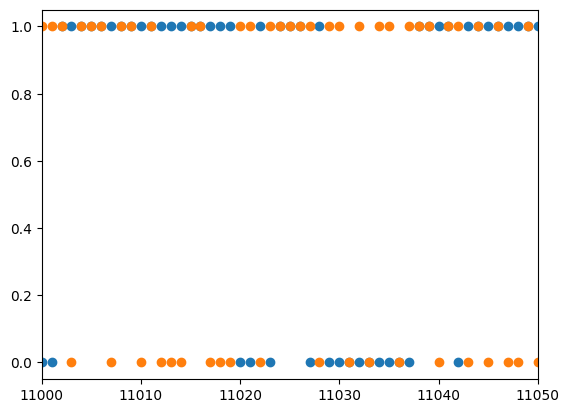

In [6]:
# show me all the sessions for Fiona in df_rev and df_ABT
print(f"Sessions for Fiona in df_rev: {df_rev[df_rev['Animal_Name'] == 'Fiona']['Session_ID'].unique()}")
print(f"Sessions for Fiona in df_ABT: {df_ABT[df_ABT['Animal_Name'] == 'Fiona']['Session_ID'].unique()}")


Sessions for Fiona in df_rev: ['2024-02-12_240212_Fiona_VDT_NoInitiation_100_Conflict_Reversal1.1'
 '2024-02-20_240220_Fiona_VDT_NoInitiation_100_Conflict_Reversal1.1'
 '2024-02-21_240221_Fiona_VDT_NoInitiation_100_Conflict_Reversal1.1'
 '2024-02-22_240222_FIona_VDT_NoInitiation_100_Conflict_Reversal1.1'
 '2024-02-23_240223_Fiona_VDT_NoInitiation_100_Conflict_Reversal1.1'
 '2024-02-27_20240227_Fiona_Reversal1.1 '
 '2024-02-29_240229_Fiona_VDT_NoInitiation_100_Conflict_Reversal1.1']
Sessions for Fiona in df_ABT: ['2022-04-25_20220425_Fiona_Reversal3.1'
 '2022-04-26_20220426_Fiona_Reversal3.1'
 '2022-05-02_20220502_Fiona_Reversal3.1'
 '2022-05-03_20220503_Fiona_Reversal3.1(1)'
 '2022-05-04_20220504_Fiona_Reversal3.1'
 '2022-05-05_20220505_Fiona_Reversal3.1'
 '2022-05-06_20220506_Fiona_Reversal3.1'
 '2022-05-09_20220509_Fiona_Reversal3.1'
 '2022-05-10_20220510_Fiona_Reversal3.1'
 '2022-05-12_20220512_Fiona_Reversal3.1'
 '2022-05-13_20220513_Fiona_Reversal3.1'
 '2022-05-16_20220516_Fiona_R

In [5]:
# identify sessions that are in both df_rev and df_ABT
sessions_in_both = set(df_rev['Session_ID']) & set(df_ABT['Session_ID'])

print(f"Sessions in both df_rev and df_ABT: {len(sessions_in_both)}")



Sessions in both df_rev and df_ABT: 0


In [2]:
# Font Preferences and graph styles
# ============================================================================

import matplotlib.pyplot as plt

# Global font and line settings
FONTSIZE = 8
LINE_WIDTH = 0.5
TICK_LENGTH = 2

# Apply to matplotlib rcParams
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = FONTSIZE
plt.rcParams['axes.linewidth'] = LINE_WIDTH
plt.rcParams['xtick.major.width'] = LINE_WIDTH
plt.rcParams['ytick.major.width'] = LINE_WIDTH
plt.rcParams['xtick.major.size'] = TICK_LENGTH
plt.rcParams['ytick.major.size'] = TICK_LENGTH
plt.rcParams['lines.linewidth'] = LINE_WIDTH
plt.rcParams['svg.fonttype'] = 'none'  # Save text as text (not paths)

# STANDARD ANIMAL CONFIGURATION - USE IN ALL NOTEBOOKS
# ============================================================================

# Standard animal order (left to right in all plots)
ANIMAL_ORDER = [
    'Coral',
    'Tuna',
    'Fiona',
    'Salmon',
    'Knuckles',
    'Raven', 
    'Sonic',
    'Zazu',
    'Griffin',
    'Sunflower',

]

# Standard animal colors (matching your asymptotic performance figure)
ANIMAL_COLORS = {
    'Coral': '#e74c3c',      # Coral/Red
    'Raven': '#2ecc71',      # Green
    'Tuna': '#8b7355',       # Brown/Tan
    'Sonic': '#34495e',      # Dark Gray
    'Griffin': '#9b59b6',    # Purple
    'Sunflower': '#1abc9c',  # Teal/Cyan
    'Zazu': '#3498db',       # Light Blue
    'Salmon': '#f39c12',     # Orange/Yellow
    'Fiona':  '#e91e63',      # Pink/Magenta
    'Knuckles': '#e67e22'    # Orange/Brown
}

# Helper function to get colors in correct order
def get_ordered_colors(animals):
    """Return colors for given animals in standard order"""
    ordered_animals = [a for a in ANIMAL_ORDER if a in animals]
    return [ANIMAL_COLORS[a] for a in ordered_animals]

# Helper function to sort animals
def sort_animals(animal_list):
    """Sort animals according to standard order"""
    return sorted(animal_list, key=lambda x: ANIMAL_ORDER.index(x) if x in ANIMAL_ORDER else 999)

In [12]:
# At the beginning of the notebook, after loading data:
df = df.sort_values(['Session_ID']).reset_index(drop=True)
df['Prev_StartTime'] = df.groupby('Session_ID')['AbsoluteTrialStartTime'].shift(1)
df['ITI'] = (df['AbsoluteTrialStartTime'] - df['Prev_StartTime']) / 1000

In [4]:
# ============================================================================
# CELL 3: Analyze Cued vs Uncued Transitions (FIXED)
# ============================================================================

print("Analyzing cued vs uncued transitions...\n")

# Look at sample session
sample_session = df['Session_ID'].iloc[0]
sample_df = df[df['Session_ID'] == sample_session].sort_values('Trial')

print(f"Sample session: {sample_session}")
print(f"  Animal: {sample_df['Animal_Name'].iloc[0]}")
print(f"  Total reversals: {sample_df['Num_Reversals'].iloc[0]}")
print(f"  Cued transitions: {sample_df['Num_Cued_Transitions'].iloc[0]}")

# Check transitions
blocks = sorted(sample_df['Block'].unique())
print(f"\nAnalyzing {len(blocks)-1} block transitions:")

for i in range(len(blocks)-1):
    curr_block = blocks[i]
    next_block = blocks[i+1]
    
    block_i_trials = sample_df[sample_df['Block'] == curr_block]
    block_i1_trials = sample_df[sample_df['Block'] == next_block]
    
    if len(block_i_trials) > 0 and len(block_i1_trials) > 0:
        block_i = block_i_trials.iloc[-1]
        block_i1 = block_i1_trials.iloc[0]
        
        print(f"\nBlock {curr_block} → Block {next_block}:")
        
        # Check if Target1_location exists
        if 'Target1_location' in df.columns:
            print(f"  Target1 location: {block_i['Target1_location']} → {block_i1['Target1_location']}")
            print(f"  Target2 location: {block_i['Target2_location']} → {block_i1['Target2_location']}")
            
            loc_changed = (block_i['Target1_location'] != block_i1['Target1_location'])
        else:
            print("  (Target locations not in dataset)")
            loc_changed = False
        
        # Check stimulus sources
        stim_changed = (block_i.get('TaskObject2_Source') != block_i1.get('TaskObject2_Source'))
        
        print(f"  Locations changed: {loc_changed}")
        print(f"  Stimuli changed: {stim_changed}")
        
        if loc_changed and stim_changed:
            transition_type = "CUED"
        elif not loc_changed and not stim_changed:
            transition_type = "UNCUED"
        else:
            transition_type = "PARTIAL"
        
        print(f"  → {transition_type} transition")

print("\n" + "="*70)
print("SUMMARY ACROSS ALL SESSIONS")
print("="*70)

# Count transition types across all sessions
all_transitions = []

for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial')
    blocks = sorted(session_df['Block'].unique())
    
    for i in range(len(blocks)-1):
        curr_block = blocks[i]
        next_block = blocks[i+1]
        
        block_i = session_df[session_df['Block'] == curr_block].iloc[-1]
        block_i1 = session_df[session_df['Block'] == next_block].iloc[0]
        
        if 'Target1_location' in df.columns:
            loc_changed = (block_i['Target1_location'] != block_i1['Target1_location'])
        else:
            loc_changed = False
        
        stim_changed = (block_i.get('TaskObject2_Source') != block_i1.get('TaskObject2_Source'))
        
        if loc_changed and stim_changed:
            transition_type = "CUED"
        elif not loc_changed and not stim_changed:
            transition_type = "UNCUED"
        else:
            transition_type = "PARTIAL"
        
        all_transitions.append({
            'session_id': session_id,
            'from_block': curr_block,
            'to_block': next_block,
            'transition_type': transition_type,
            'animal': session_df['Animal_Name'].iloc[0]
        })

trans_df = pd.DataFrame(all_transitions)

print(f"\nTotal transitions: {len(trans_df)}")
print(f"\nTransition types:")
print(trans_df['transition_type'].value_counts())

print(f"\nTransitions per session:")
print(f"  Mean: {len(trans_df) / df['Session_ID'].nunique():.1f}")
print(f"  Range: {trans_df.groupby('session_id').size().min()} - {trans_df.groupby('session_id').size().max()}")

print("="*70)

Analyzing cued vs uncued transitions...

Sample session: 2024-02-12_240212_Fiona_VDT_NoInitiation_100_Conflict_Reversal1.1
  Animal: Fiona
  Total reversals: 2.0
  Cued transitions: 1.0

Analyzing 3 block transitions:

Block 1 → Block 2:
  Target1 location: RightCenter → LeftCenter
  Target2 location: LeftCenter → RightCenter
  Locations changed: True
  Stimuli changed: True
  → CUED transition

Block 2 → Block 3:
  Target1 location: LeftCenter → TopRight
  Target2 location: RightCenter → TopLeft
  Locations changed: True
  Stimuli changed: True
  → CUED transition

Block 3 → Block 4:
  Target1 location: TopRight → TopLeft
  Target2 location: TopLeft → TopRight
  Locations changed: True
  Stimuli changed: True
  → CUED transition

SUMMARY ACROSS ALL SESSIONS

Total transitions: 165

Transition types:
transition_type
CUED       162
PARTIAL      3
Name: count, dtype: int64

Transitions per session:
  Mean: 3.1
  Range: 2 - 9


In [13]:
# ============================================================================
# Investigate how to identify uncued reversals
# ============================================================================

print("Investigating uncued reversal identification...\n")

# The session says: 2 reversals, 1 cued transition
# That means: 1 cued + 2 uncued = 3 total transitions
# But we're seeing all locations change...

# Let's check if there's a "Switch" column that marks reversals
print("Checking 'Switch' column:")
print(df['PhysicalSwitch'].value_counts())

# Let's look trial-by-trial at the sample session
sample_df = df[df['Session_ID'] == sample_session].sort_values('Trial')

print(f"\n" + "="*70)
print("TRIAL-BY-TRIAL ANALYSIS")
print("="*70)

# Show trials around each block transition
blocks = sorted(sample_df['Block'].unique())

for i in range(len(blocks)-1):
    curr_block = blocks[i]
    next_block = blocks[i+1]
    
    # Get last 3 trials of current block and first 3 of next
    last_trials = sample_df[sample_df['Block'] == curr_block].tail(3)
    first_trials = sample_df[sample_df['Block'] == next_block].head(3)
    
    print(f"\n{'='*70}")
    print(f"Block {curr_block} → Block {next_block}")
    print(f"{'='*70}")
    
    print("\nLast 3 trials of previous block:")
    for _, trial in last_trials.iterrows():
        print(f"  Trial {trial['Trial']}: {trial['StimuliChosen']} at {trial['PhysicalChoice']} → Reward={trial['Reward']} (Switch={trial['PhysicalSwitch']})")
    
    print("\nFirst 3 trials of new block:")
    for _, trial in first_trials.iterrows():
        print(f"  Trial {trial['Trial']}: {trial['StimuliChosen']} at {trial['PhysicalChoice']} → Reward={trial['Reward']} (Switch={trial['PhysicalSwitch']})")
    
    # Check what actually changed
    last_trial = last_trials.iloc[-1]
    first_trial = first_trials.iloc[0]
    
    print(f"\nWhat changed:")
    print(f"  Target1_location: {last_trial['Target1_location']} → {first_trial['Target1_location']}")
    print(f"  Target2_location: {last_trial['Target2_location']} → {first_trial['Target2_location']}")
    print(f"  Switch value: {first_trial['PhysicalSwitch']}")
    
    # Check if the HIGH-PROB location flipped (uncued) or moved to new location (cued)
    # In an UNCUED reversal: locations stay same, but which one is rewarded flips
    # In a CUED transition: locations change entirely

print("\n" + "="*70)
print("KEY INSIGHT")
print("="*70)
print("\nMaybe 'Switch' column marks uncued reversals?")
print(f"Sessions with Switch=1: {df[df['PhysicalSwitch']==1]['Session_ID'].nunique()}")
print(f"Total Switch=1 events: {(df['PhysicalSwitch']==1).sum()}")

Investigating uncued reversal identification...

Checking 'Switch' column:
PhysicalSwitch
0.0    9053
1.0    2378
Name: count, dtype: int64

TRIAL-BY-TRIAL ANALYSIS

Block 1 → Block 2

Last 3 trials of previous block:
  Trial 178: TargetB at LeftCenter → Reward=Unrewarded (Switch=1.0)
  Trial 179: TargetB at LeftCenter → Reward=Unrewarded (Switch=0.0)
  Trial 180: TargetB at LeftCenter → Reward=Unrewarded (Switch=0.0)

First 3 trials of new block:
  Trial 21: TargetA at LeftCenter → Reward=Rewarded (Switch=0.0)
  Trial 22: TargetA at LeftCenter → Reward=Rewarded (Switch=0.0)
  Trial 23: TargetA at LeftCenter → Reward=Rewarded (Switch=0.0)

What changed:
  Target1_location: RightCenter → LeftCenter
  Target2_location: LeftCenter → RightCenter
  Switch value: 0.0

Block 2 → Block 3

Last 3 trials of previous block:
  Trial 198: TargetA at LeftCenter → Reward=Rewarded (Switch=0.0)
  Trial 199: TargetA at LeftCenter → Reward=Rewarded (Switch=0.0)
  Trial 200: TargetA at LeftCenter → Reward

In [14]:
# ============================================================================
# Verify transition classification for sample session
# ============================================================================

print("Verifying transition classification...\n")

sample_df = df[df['Session_ID'] == sample_session].sort_values('Trial')
blocks = sorted(sample_df['Block'].unique())

print(f"Sample session: {sample_session}")
print(f"  Num_Reversals (uncued): {sample_df['Num_Reversals'].iloc[0]}")
print(f"  Num_Cued_Transitions: {sample_df['Num_Cued_Transitions'].iloc[0]}")
print(f"  Expected: 2 uncued + 1 cued = 3 total\n")

for i in range(len(blocks)-1):
    curr_block = blocks[i]
    next_block = blocks[i+1]
    
    curr_trials = sample_df[sample_df['Block'] == curr_block]
    next_trials = sample_df[sample_df['Block'] == next_block]
    
    # Get unique locations
    curr_locs = set(curr_trials['PhysicalChoice'].dropna().unique())
    next_locs = set(next_trials['PhysicalChoice'].dropna().unique())
    
    # Check if same locations
    same_locations = (curr_locs == next_locs)
    
    if same_locations:
        trans_type = "UNCUED"
    else:
        trans_type = "CUED"
    
    print(f"Block {curr_block} → {next_block}:")
    print(f"  Current block locations: {curr_locs}")
    print(f"  Next block locations: {next_locs}")
    print(f"  Same locations? {same_locations}")
    print(f"  → {trans_type}\n")

print("="*70)
print("Does this match expected pattern?")
print("  Block 1→2: UNCUED ✓")
print("  Block 2→3: CUED ✓")
print("  Block 3→4: UNCUED ✓")
print("="*70)

Verifying transition classification...

Sample session: 2024-02-12_240212_Fiona_VDT_NoInitiation_100_Conflict_Reversal1.1
  Num_Reversals (uncued): 2.0
  Num_Cued_Transitions: 1.0
  Expected: 2 uncued + 1 cued = 3 total

Block 1 → 2:
  Current block locations: {'RightCenter', 'LeftCenter'}
  Next block locations: {'RightCenter', 'LeftCenter'}
  Same locations? True
  → UNCUED

Block 2 → 3:
  Current block locations: {'RightCenter', 'LeftCenter'}
  Next block locations: {'TopLeft', 'TopRight'}
  Same locations? False
  → CUED

Block 3 → 4:
  Current block locations: {'TopLeft', 'TopRight'}
  Next block locations: {'TopLeft', 'TopRight'}
  Same locations? True
  → UNCUED

Does this match expected pattern?
  Block 1→2: UNCUED ✓
  Block 2→3: CUED ✓
  Block 3→4: UNCUED ✓


In [15]:
# ============================================================================
# CLASSIFY ALL TRANSITIONS: Cued vs Uncued
# ============================================================================

print("Classifying all transitions across all sessions...\n")

all_transitions = []

for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial')
    blocks = sorted(session_df['Block'].unique())
    
    for i in range(len(blocks)-1):
        curr_block = blocks[i]
        next_block = blocks[i+1]
        
        curr_trials = session_df[session_df['Block'] == curr_block]
        next_trials = session_df[session_df['Block'] == next_block]
        
        # Get unique locations
        curr_locs = set(curr_trials['PhysicalChoice'].dropna().unique())
        next_locs = set(next_trials['PhysicalChoice'].dropna().unique())
        
        # Classify
        if curr_locs == next_locs:
            trans_type = "UNCUED"
        else:
            trans_type = "CUED"
        
        all_transitions.append({
            'session_id': session_id,
            'from_block': curr_block,
            'to_block': next_block,
            'transition_type': trans_type,
            'animal': session_df['Animal_Name'].iloc[0],
            'date': session_df['Date'].iloc[0]
        })

trans_df = pd.DataFrame(all_transitions)

print("="*70)
print("TRANSITION CLASSIFICATION COMPLETE")
print("="*70)

print(f"\nTotal transitions: {len(trans_df)}")
print(f"\nTransition types:")
print(trans_df['transition_type'].value_counts())

print(f"\nTransitions per session:")
trans_per_session = trans_df.groupby('session_id').size()
print(f"  Mean: {trans_per_session.mean():.1f}")
print(f"  Range: {trans_per_session.min()} - {trans_per_session.max()}")

print(f"\nBy animal:")
for animal in sort_animals(trans_df['animal'].unique()):
    animal_trans = trans_df[trans_df['animal'] == animal]
    n_sessions = animal_trans['session_id'].nunique()
    n_cued = (animal_trans['transition_type'] == 'CUED').sum()
    n_uncued = (animal_trans['transition_type'] == 'UNCUED').sum()
    print(f"  {animal}: {n_sessions} sessions, {n_cued} cued, {n_uncued} uncued")

# Save this classification for later use
df = df.sort_values(['Session_ID', 'Trial']).reset_index(drop=True)
df['Transition_Type'] = None

for idx, trans in trans_df.iterrows():
    # Mark the first trial of the new block with the transition type
    session_data = df[df['Session_ID'] == trans['session_id']]
    first_trial_idx = session_data[session_data['Block'] == trans['to_block']].index[0]
    df.loc[first_trial_idx, 'Transition_Type'] = trans['transition_type']

print(f"\n✓ Transition types added to dataframe")
print("="*70)

Classifying all transitions across all sessions...

TRANSITION CLASSIFICATION COMPLETE

Total transitions: 165

Transition types:
transition_type
UNCUED    103
CUED       62
Name: count, dtype: int64

Transitions per session:
  Mean: 3.1
  Range: 2 - 9

By animal:
  Coral: 10 sessions, 13 cued, 18 uncued
  Fiona: 7 sessions, 6 cued, 15 uncued
  Knuckles: 5 sessions, 10 cued, 11 uncued
  Sonic: 9 sessions, 9 cued, 18 uncued
  Zazu: 12 sessions, 13 cued, 22 uncued
  Sunflower: 10 sessions, 11 cued, 19 uncued

✓ Transition types added to dataframe


Creating cued vs uncued reversal comparison...

Reversal-aligned data: 4986 trials
  Cued: 1843 trials
  Uncued: 3143 trials


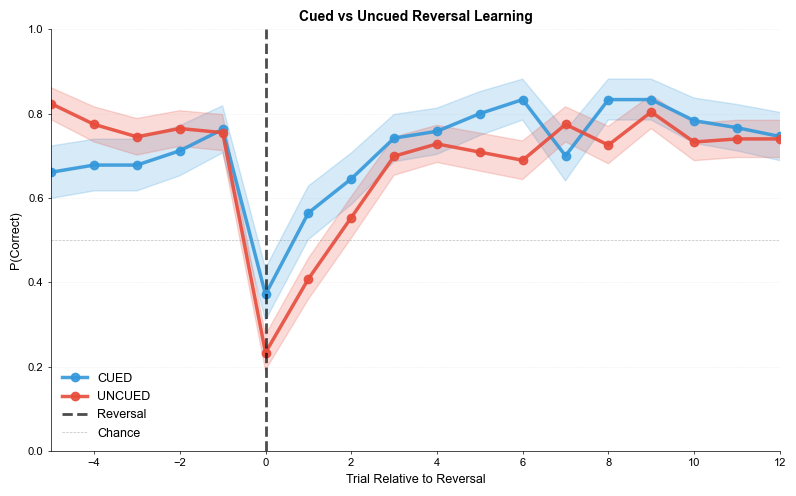


✓ Figure created!


In [17]:
# Figure 2: Cued vs Uncued Reversal Learning
# ============================================================================

print("Creating cued vs uncued reversal comparison...\n")

# Create reversal-aligned data
reversal_aligned_data = []

for idx, trans in trans_df.iterrows():
    session_id = trans['session_id']
    to_block = trans['to_block']
    trans_type = trans['transition_type']
    animal = trans['animal']
    
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial')
    
    # Find the first trial of the new block (reversal point)
    new_block_trials = session_data[session_data['Block'] == to_block]
    
    if len(new_block_trials) > 0:
        reversal_trial = new_block_trials['Trial'].iloc[0]
        
        # Get trials -10 to +20 relative to reversal
        for rel_trial in range(-10, 21):
            abs_trial = reversal_trial + rel_trial
            trial_data = session_data[session_data['Trial'] == abs_trial]
            
            if len(trial_data) > 0:
                reversal_aligned_data.append({
                    'session_id': session_id,
                    'animal': animal,
                    'transition_type': trans_type,
                    'trial_relative': rel_trial,
                    'outcome': trial_data['Outcome'].iloc[0],  # Use Decision (correct choice)
                    'reward': trial_data['Reward'].iloc[0]
                })

rev_df = pd.DataFrame(reversal_aligned_data)

print(f"Reversal-aligned data: {len(rev_df)} trials")
print(f"  Cued: {len(rev_df[rev_df['transition_type']=='CUED'])} trials")
print(f"  Uncued: {len(rev_df[rev_df['transition_type']=='UNCUED'])} trials")

# Create learning curves
fig, ax = plt.subplots(figsize=(8, 5))

BIN_SIZE = 1

for trans_type, color in [('CUED', '#3498db'), ('UNCUED', '#e74c3c')]:
    type_data = rev_df[rev_df['transition_type'] == trans_type].copy()
    type_data['trial_bin'] = (type_data['trial_relative'] // BIN_SIZE) * BIN_SIZE
    
    binned = type_data.groupby('trial_bin').agg({
        'outcome': ['mean', 'sem']
    }).reset_index()
    binned.columns = ['trial_bin', 'accuracy', 'sem']
    
    ax.plot(binned['trial_bin'], binned['accuracy'],
           'o-', color=color, linewidth=2.5, markersize=6,
           label=trans_type, alpha=0.9)
    ax.fill_between(binned['trial_bin'],
                    binned['accuracy'] - binned['sem'],
                    binned['accuracy'] + binned['sem'],
                    color=color, alpha=0.2)

ax.axvline(0, color='black', linestyle='--', linewidth=2, 
          alpha=0.7, label='Reversal')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, 
          alpha=0.5, label='Chance')

ax.set_xlabel('Trial Relative to Reversal', fontsize=FONTSIZE+1)
ax.set_ylabel('P(Correct)', fontsize=FONTSIZE+1)
ax.set_title('Cued vs Uncued Reversal Learning', fontsize=FONTSIZE+2, fontweight='bold')
ax.set_xlim(-5, 12)
ax.set_ylim(0.0, 1.0)
ax.legend(fontsize=FONTSIZE+1, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Cued_vs_Uncued_Learning_Curves.svg'), dpi=300)
plt.show()

print("\n✓ Figure created!")

In [107]:
trans_df

,session_id,from_block,to_block,transition_type,animal,date
0,2023-08-11_20230811_Knuckles_Reversal1.1,1,2,UNCUED,Knuckles,2023-08-11
1,2023-08-11_20230811_Knuckles_Reversal1.1,2,3,CUED,Knuckles,2023-08-11
2,2023-08-11_20230811_Knuckles_Reversal1.1,3,4,UNCUED,Knuckles,2023-08-11
3,2023-08-14_20230814_Knuckles_Reversal1.1,1,2,UNCUED,Knuckles,2023-08-14
4,2023-08-14_20230814_Knuckles_Reversal1.1,2,3,CUED,Knuckles,2023-08-14
5,2023-08-14_20230814_Knuckles_Reversal1.1,3,4,UNCUED,Knuckles,2023-08-14
6,2023-08-15_20230815_Knuckles_Reversal1.1,5,6,UNCUED,Knuckles,2023-08-15
7,2023-08-15_20230815_Knuckles_Reversal1.1,6,7,CUED,Knuckles,2023-08-15
8,2023-08-15_20230815_Knuckles_Reversal1.1,7,8,UNCUED,Knuckles,2023-08-15
9,2023-08-16_20230816_Knuckles_Reversal1.1,7,8,UNCUED,Knuckles,2023-08-16


Creating physical switch comparison (cued vs uncued)...

Switch-aligned data: 4982 trials


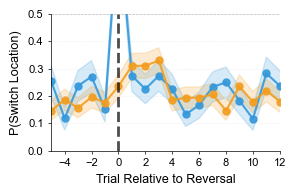


✓ Switch rate figure created!

SWITCH RATE STATISTICS

CUED:
  Pre-reversal: 19.7%
  Early post (0-4): 36.5%
  Late post (10+): 21.3%
  Increase at reversal: +16.8pp
Figure is saved at /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/Reversal_100-0_Block_Learning/Cued_vs_Uncued_Switch_Rate_100-0.svg

UNCUED:
  Pre-reversal: 17.8%
  Early post (0-4): 27.4%
  Late post (10+): 25.7%
  Increase at reversal: +9.6pp
Figure is saved at /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/Reversal_100-0_Block_Learning/Cued_vs_Uncued_Switch_Rate_100-0.svg


In [121]:
# Cued vs Uncued: Physical Switch Rate
# ============================================================================

print("Creating physical switch comparison (cued vs uncued)...\n")

# Create reversal-aligned switch data
switch_aligned_data = []

for idx, trans in trans_df.iterrows():
    session_id = trans['session_id']
    to_block = trans['to_block']
    trans_type = trans['transition_type']
    animal = trans['animal']
    
    session_data = df[df['Session_ID'] == session_id].sort_values('Trial')
    
    # Find the reversal point
    new_block_trials = session_data[session_data['Block'] == to_block]
    
    if len(new_block_trials) > 0:
        reversal_trial = new_block_trials['Trial'].iloc[0]
        
        # Get trials -10 to +20 relative to reversal
        for rel_trial in range(-10, 21):
            abs_trial = reversal_trial + rel_trial
            trial_data = session_data[session_data['Trial'] == abs_trial]
            
            if len(trial_data) > 0 and not pd.isna(trial_data['PhysicalSwitch'].iloc[0]):
                switch_aligned_data.append({
                    'session_id': session_id,
                    'animal': animal,
                    'transition_type': trans_type,
                    'trial_relative': rel_trial,
                    'physical_switch': trial_data['PhysicalSwitch'].iloc[0],
                    'outcome': trial_data['Outcome'].iloc[0]
                })

switch_df = pd.DataFrame(switch_aligned_data)

print(f"Switch-aligned data: {len(switch_df)} trials")

# Create switch rate curves
fig, ax = plt.subplots(figsize=(3, 2))

BIN_SIZE = 1

for trans_type, color in [('CUED', '#3498db'), ('UNCUED', '#f29d1f')]:
    type_data = switch_df[switch_df['transition_type'] == trans_type].copy()
    type_data['trial_bin'] = (type_data['trial_relative'] // BIN_SIZE) * BIN_SIZE
    
    binned = type_data.groupby('trial_bin').agg({
        'physical_switch': ['mean', 'sem']
    }).reset_index()
    binned.columns = ['trial_bin', 'switch_rate', 'sem']
    
    ax.plot(binned['trial_bin'], binned['switch_rate'],
           'o-', color=color, linewidth=1.5, markersize=5,
           label=trans_type, alpha=0.9)
    ax.fill_between(binned['trial_bin'],
                    binned['switch_rate'] - binned['sem'],
                    binned['switch_rate'] + binned['sem'],
                    color=color, alpha=0.2)

ax.axvline(0, color='black', linestyle='--', linewidth=2, 
          alpha=0.7, label='Reversal')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, 
          alpha=0.5, label='Random')

ax.set_xlabel('Trial Relative to Reversal', fontsize=FONTSIZE+1)
ax.set_ylabel('P(Switch Location)', fontsize=FONTSIZE+1)
# ax.set_title('Physical Switching: Cued vs Uncued Reversals', 
#             fontsize=FONTSIZE+2, fontweight='bold')
ax.set_xlim(-5, 12)
# set x lim marks at -4, -2, 0, 2, 4, 6, 8, 10, 12
ax.set_xticks([-4, -2, 0, 2, 4, 6, 8, 10, 12])
ax.set_ylim(0, 0.5)
# ax.legend(fontsize=FONTSIZE+1, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, f'Cued_vs_Uncued_Switch_Rate_{PROB_CONDITION}.svg'), dpi=300)
plt.show()

print("\n✓ Switch rate figure created!")

# Print statistics
print("\n" + "="*70)
print("SWITCH RATE STATISTICS")
print("="*70)

for trans_type in ['CUED', 'UNCUED']:
    type_data = switch_df[switch_df['transition_type'] == trans_type]
    
    pre_rev = type_data[type_data['trial_relative'] < 0]['physical_switch'].mean()
    early_post = type_data[(type_data['trial_relative'] >= 0) & 
                           (type_data['trial_relative'] < 5)]['physical_switch'].mean()
    late_post = type_data[type_data['trial_relative'] >= 10]['physical_switch'].mean()
    
    print(f"\n{trans_type}:")
    print(f"  Pre-reversal: {pre_rev*100:.1f}%")
    print(f"  Early post (0-4): {early_post*100:.1f}%")
    print(f"  Late post (10+): {late_post*100:.1f}%")
    print(f"  Increase at reversal: {(early_post - pre_rev)*100:+.1f}pp")
    print(f"Figure is saved at {FIGURE_PATH}/Cued_vs_Uncued_Switch_Rate_{PROB_CONDITION}.svg")

print("="*70)

In [ ]:
# Debug: Check reversal alignment
# ============================================================================

print("Checking reversal alignment...\n")

# Look at one specific reversal in detail
sample_reversal = trans_df.iloc[0]
session_id = sample_reversal['session_id']
from_block = sample_reversal['from_block']
to_block = sample_reversal['to_block']
trans_type = sample_reversal['transition_type']

session_data = df[df['Session_ID'] == session_id].sort_values('Trial')

print(f"Session: {session_id}")
print(f"Transition: Block {from_block} → {to_block} ({trans_type})")

# Get last 5 trials of old block
old_block_last = session_data[session_data['Block'] == from_block].tail(5)
# Get first 5 trials of new block
new_block_first = session_data[session_data['Block'] == to_block].head(5)

print("\nLast 5 trials of OLD block:")
for _, trial in old_block_last.iterrows():
    print(f"  Trial {trial['Trial']}: Block={trial['Block']}, Choice={trial['PhysicalChoice']}, Outcome={trial['Outcome']}")

print("\nFirst 5 trials of NEW block:")
for _, trial in new_block_first.iterrows():
    print(f"  Trial {trial['Trial']}: Block={trial['Block']}, Choice={trial['PhysicalChoice']}, Outcome={trial['Outcome']}")

# Check what we're calling "position 0"
reversal_trial = new_block_first['Trial'].iloc[0]
print(f"\nCurrent code sets reversal point at Trial {reversal_trial} (first trial of new block)")
print(f"This means:")
print(f"  Position -1 = Trial {reversal_trial - 1} (last trial of old block)")
print(f"  Position 0 = Trial {reversal_trial} (first trial of new block)")
print(f"  Position +1 = Trial {reversal_trial + 1} (second trial of new block)")

print("\nIs this correct?")

Checking reversal alignment...

Session: 2024-02-12_240212_Fiona_VDT_NoInitiation_100_Conflict_Reversal1.1
Transition: Block 1 → 2 (UNCUED)

Last 5 trials of OLD block:
  Trial 176: Block=1, Choice=RightCenter, Outcome=1
  Trial 177: Block=1, Choice=RightCenter, Outcome=1
  Trial 178: Block=1, Choice=LeftCenter, Outcome=0
  Trial 179: Block=1, Choice=LeftCenter, Outcome=0
  Trial 180: Block=1, Choice=LeftCenter, Outcome=0

First 5 trials of NEW block:
  Trial 21: Block=2, Choice=LeftCenter, Outcome=1
  Trial 22: Block=2, Choice=LeftCenter, Outcome=1
  Trial 23: Block=2, Choice=LeftCenter, Outcome=1
  Trial 24: Block=2, Choice=LeftCenter, Outcome=1
  Trial 25: Block=2, Choice=LeftCenter, Outcome=1

Current code sets reversal point at Trial 21 (first trial of new block)
This means:
  Position -1 = Trial 20 (last trial of old block)
  Position 0 = Trial 21 (first trial of new block)
  Position +1 = Trial 22 (second trial of new block)

Is this correct?


In [ ]:
# Debug: Why are absolute positions jumping?
# ============================================================================

print("Investigating position jump...\n")

sample_session_data = df[df['Session_ID'] == session_id].copy()

# Check the raw data around the transition
print("All trials sorted by AbsoluteTrialStartTime:")
sample_sorted = sample_session_data.sort_values('AbsoluteTrialStartTime')

# Show trials around the problematic area
for idx, trial in sample_sorted.iterrows():
    if 175 <= trial['Abs_Trial_Pos'] <= 185 or 18 <= trial['Abs_Trial_Pos'] <= 26:
        print(f"  Abs={trial['Abs_Trial_Pos']:3d}, Trial={trial['Trial']:3d}, Block={trial['Block']}, Time={trial['AbsoluteTrialStartTime']:.1f}")

print("\n" + "="*70)
print("The problem: Blocks are being presented out of chronological order!")
print("="*70)

# Solution: Sort by Trial within each Block to reconstruct chronological order
print("\nRecreating proper chronological order...")

# Within each session, sort by Block then Trial
sample_chrono = sample_session_data.sort_values(['Block', 'Trial'])
sample_chrono['True_Abs_Pos'] = range(len(sample_chrono))

print("\nCorrected order:")
print("\nLast 5 of Block 1:")
for _, trial in sample_chrono[sample_chrono['Block'] == 1].tail(5).iterrows():
    print(f"  True abs={trial['True_Abs_Pos']:3d}, Trial={trial['Trial']:3d}, Block={trial['Block']}")

print("\nFirst 5 of Block 2:")
for _, trial in sample_chrono[sample_chrono['Block'] == 2].head(5).iterrows():
    print(f"  True abs={trial['True_Abs_Pos']:3d}, Trial={trial['Trial']:3d}, Block={trial['Block']}")

Investigating position jump...

All trials sorted by AbsoluteTrialStartTime:


KeyError: 'Abs_Trial_Pos'

In [19]:
# Correctly create absolute trial positions (sort by Block, then Trial)
# ============================================================================

print("Creating correct absolute trial positions...\n")

# For each session, sort by Block then Trial to get chronological order
df_corrected = []

for session_id in df['Session_ID'].unique():
    session_data = df[df['Session_ID'] == session_id].copy()
    session_data = session_data.sort_values(['Block', 'Trial'])
    session_data['Abs_Trial_Pos'] = range(len(session_data))
    df_corrected.append(session_data)

df = pd.concat(df_corrected, ignore_index=True)

print(f"✓ Corrected absolute positions created")

# Now redo the reversal-aligned analysis
print("\nRecreating reversal-aligned data with correct positions...\n")

reversal_aligned_data = []

for idx, trans in trans_df.iterrows():
    session_id = trans['session_id']
    to_block = trans['to_block']
    trans_type = trans['transition_type']
    animal = trans['animal']
    
    session_data = df[df['Session_ID'] == session_id]
    
    # Find first trial of new block
    new_block_trials = session_data[session_data['Block'] == to_block]
    
    if len(new_block_trials) > 0:
        reversal_abs_pos = new_block_trials['Abs_Trial_Pos'].iloc[0]
        
        # Get trials -10 to +20 relative to reversal
        for rel_trial in range(-10, 21):
            abs_pos = reversal_abs_pos + rel_trial
            trial_data = session_data[session_data['Abs_Trial_Pos'] == abs_pos]
            
            if len(trial_data) > 0:
                reversal_aligned_data.append({
                    'session_id': session_id,
                    'animal': animal,
                    'transition_type': trans_type,
                    'trial_relative': rel_trial,
                    'outcome': trial_data['Outcome'].iloc[0],
                    'physical_switch': trial_data['PhysicalSwitch'].iloc[0]
                })

rev_df = pd.DataFrame(reversal_aligned_data)

print(f"Reversal-aligned data: {len(rev_df)} trials")
print(f"  Cued: {len(rev_df[rev_df['transition_type']=='CUED'])} trials")
print(f"  Uncued: {len(rev_df[rev_df['transition_type']=='UNCUED'])} trials")

print("\n✓ Data recreated with correct trial positions!")
print("\nNow rerun the plotting code to see the corrected curves.")

Creating correct absolute trial positions...

✓ Corrected absolute positions created

Recreating reversal-aligned data with correct positions...

Reversal-aligned data: 5018 trials
  Cued: 1873 trials
  Uncued: 3145 trials

✓ Data recreated with correct trial positions!

Now rerun the plotting code to see the corrected curves.


In [20]:
# Check PhysicalSwitch column
print("Checking PhysicalSwitch column:\n")

print(f"Column exists: {'PhysicalSwitch' in df.columns}")

if 'PhysicalSwitch' in df.columns:
    print(f"\nPhysicalSwitch values:")
    print(df['PhysicalSwitch'].value_counts(dropna=False))
    
    print(f"\nSample data:")
    sample = df[['Session_ID', 'Trial', 'Block', 'PhysicalChoice', 'PhysicalSwitch', 'Outcome']].head(10)
    print(sample)
    
    # Check if it's in rev_df
    print(f"\n\nIn reversal-aligned data:")
    print(f"  Rows with PhysicalSwitch: {rev_df['physical_switch'].notna().sum()}")
    print(f"  Rows with NaN: {rev_df['physical_switch'].isna().sum()}")
else:
    print("\n⚠️ PhysicalSwitch column not found!")
    print("Available columns with 'switch':")
    switch_cols = [col for col in df.columns if 'switch' in col.lower()]
    print(switch_cols)

Checking PhysicalSwitch column:

Column exists: True

PhysicalSwitch values:
PhysicalSwitch
0.0    9053
1.0    2378
NaN      53
Name: count, dtype: int64

Sample data:
                                 Session_ID  Trial  Block PhysicalChoice  \
0  2023-08-11_20230811_Knuckles_Reversal1.1      1      1     LeftCenter   
1  2023-08-11_20230811_Knuckles_Reversal1.1      2      1     LeftCenter   
2  2023-08-11_20230811_Knuckles_Reversal1.1      3      1    RightCenter   
3  2023-08-11_20230811_Knuckles_Reversal1.1      4      1     LeftCenter   
4  2023-08-11_20230811_Knuckles_Reversal1.1      5      1     LeftCenter   
5  2023-08-11_20230811_Knuckles_Reversal1.1      6      1     LeftCenter   
6  2023-08-11_20230811_Knuckles_Reversal1.1      7      1    RightCenter   
7  2023-08-11_20230811_Knuckles_Reversal1.1      8      1    RightCenter   
8  2023-08-11_20230811_Knuckles_Reversal1.1      9      1    RightCenter   
9  2023-08-11_20230811_Knuckles_Reversal1.1     10      1    RightCenter

Creating corrected cued vs uncued learning curves...



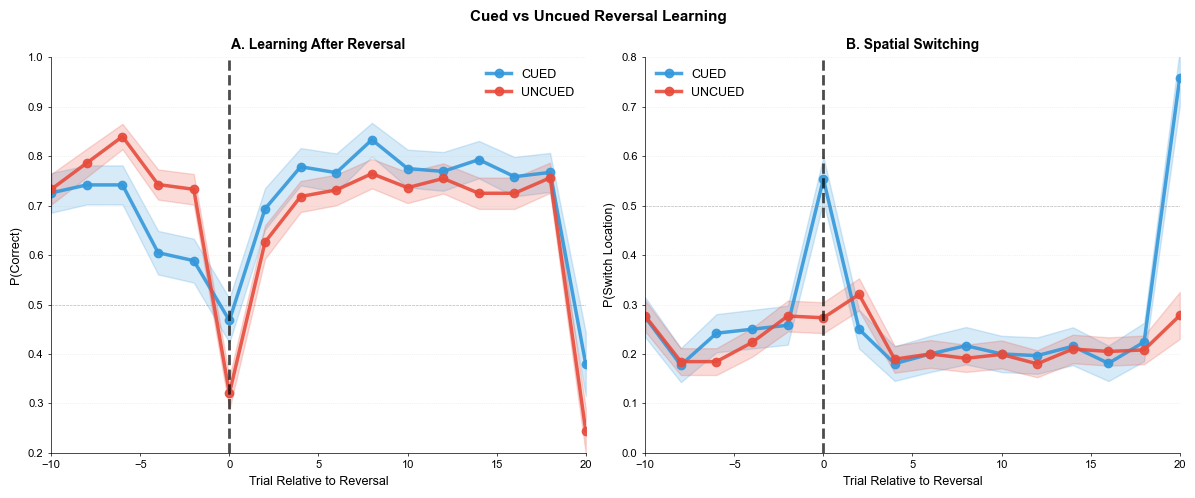


✓ Corrected figure created!


In [21]:
# Figure 2A: Cued vs Uncued Learning Curves (CORRECTED)
# ============================================================================

print("Creating corrected cued vs uncued learning curves...\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

BIN_SIZE = 2

# ========================================================================
# Panel A: Accuracy (Correct Choice)
# ========================================================================

ax = axes[0]

for trans_type, color in [('CUED', '#3498db'), ('UNCUED', '#e74c3c')]:
    type_data = rev_df[rev_df['transition_type'] == trans_type].copy()
    type_data['trial_bin'] = (type_data['trial_relative'] // BIN_SIZE) * BIN_SIZE
    
    binned = type_data.groupby('trial_bin').agg({
        'outcome': ['mean', 'sem']
    }).reset_index()
    binned.columns = ['trial_bin', 'accuracy', 'sem']
    
    ax.plot(binned['trial_bin'], binned['accuracy'],
           'o-', color=color, linewidth=2.5, markersize=6,
           label=trans_type, alpha=0.9)
    ax.fill_between(binned['trial_bin'],
                    binned['accuracy'] - binned['sem'],
                    binned['accuracy'] + binned['sem'],
                    color=color, alpha=0.2)

ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax.set_xlabel('Trial Relative to Reversal', fontsize=FONTSIZE+1)
ax.set_ylabel('P(Correct)', fontsize=FONTSIZE+1)
ax.set_title('A. Learning After Reversal', fontsize=FONTSIZE+2, fontweight='bold')
ax.set_xlim(-10, 20)
ax.set_ylim(0.2, 1.0)
ax.legend(fontsize=FONTSIZE+1, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# ========================================================================
# Panel B: Physical Switch Rate
# ========================================================================

ax = axes[1]

for trans_type, color in [('CUED', '#3498db'), ('UNCUED', '#e74c3c')]:
    type_data = rev_df[rev_df['transition_type'] == trans_type].copy()
    type_data['trial_bin'] = (type_data['trial_relative'] // BIN_SIZE) * BIN_SIZE
    
    # Remove NaN switches
    type_data = type_data[type_data['physical_switch'].notna()]
    
    binned = type_data.groupby('trial_bin').agg({
        'physical_switch': ['mean', 'sem']
    }).reset_index()
    binned.columns = ['trial_bin', 'switch_rate', 'sem']
    
    ax.plot(binned['trial_bin'], binned['switch_rate'],
           'o-', color=color, linewidth=2.5, markersize=6,
           label=trans_type, alpha=0.9)
    ax.fill_between(binned['trial_bin'],
                    binned['switch_rate'] - binned['sem'],
                    binned['switch_rate'] + binned['sem'],
                    color=color, alpha=0.2)

ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax.set_xlabel('Trial Relative to Reversal', fontsize=FONTSIZE+1)
ax.set_ylabel('P(Switch Location)', fontsize=FONTSIZE+1)
ax.set_title('B. Spatial Switching', fontsize=FONTSIZE+2, fontweight='bold')
ax.set_xlim(-10, 20)
ax.set_ylim(0, 0.8)
ax.legend(fontsize=FONTSIZE+1, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.suptitle('Cued vs Uncued Reversal Learning', fontsize=FONTSIZE+3, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Cued_vs_Uncued_Corrected.svg'), dpi=300)
plt.show()

print("\n✓ Corrected figure created!")

Calculating trials to criterion for each reversal...

Reversals analyzed: 165
Reached criterion: 155 (93.9%)

TRIALS TO CRITERION

CUED:
  Mean: 6.8 trials
  Median: 5 trials
  Range: 5 - 19
  n = 57 reversals

UNCUED:
  Mean: 8.1 trials
  Median: 7 trials
  Range: 5 - 23
  n = 98 reversals

Mann-Whitney U test (Cued < Uncued):
  U = 1994.5, p = 0.0011


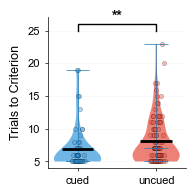


✓ Trials to criterion analysis complete!


In [22]:
# Panel C: Trials to Criterion (Cued vs Uncued)
# ============================================================================

print("Calculating trials to criterion for each reversal...\n")

CRITERION_ACCURACY = 0.8  # 80% accuracy
CRITERION_WINDOW = 5      # Over 5 consecutive trials

trials_to_criterion = []

for idx, trans in trans_df.iterrows():
    session_id = trans['session_id']
    to_block = trans['to_block']
    trans_type = trans['transition_type']
    animal = trans['animal']
    
    session_data = df[df['Session_ID'] == session_id]
    
    # Get trials from new block
    new_block_trials = session_data[session_data['Block'] == to_block].sort_values('Abs_Trial_Pos')
    
    if len(new_block_trials) >= CRITERION_WINDOW:
        # Calculate rolling accuracy
        new_block_trials = new_block_trials.copy()
        new_block_trials['rolling_acc'] = new_block_trials['Outcome'].rolling(
            window=CRITERION_WINDOW, min_periods=CRITERION_WINDOW
        ).mean()
        
        # Find first trial where rolling accuracy >= criterion
        criterion_met = new_block_trials[new_block_trials['rolling_acc'] >= CRITERION_ACCURACY]
        
        if len(criterion_met) > 0:
            ttc = criterion_met.index[0] - new_block_trials.index[0] + 1  # +1 because 0-indexed
        else:
            ttc = np.nan  # Never reached criterion
        
        trials_to_criterion.append({
            'session_id': session_id,
            'animal': animal,
            'transition_type': trans_type,
            'trials_to_criterion': ttc,
            'block_length': len(new_block_trials)
        })

ttc_df = pd.DataFrame(trials_to_criterion)

# Remove NaN and unreasonably long values
ttc_df_clean = ttc_df[ttc_df['trials_to_criterion'].notna()]
ttc_df_clean = ttc_df_clean[ttc_df_clean['trials_to_criterion'] <= 30]  # Max 30 trials

print(f"Reversals analyzed: {len(ttc_df)}")
print(f"Reached criterion: {len(ttc_df_clean)} ({len(ttc_df_clean)/len(ttc_df)*100:.1f}%)")

# Statistics
print("\n" + "="*70)
print("TRIALS TO CRITERION")
print("="*70)

for trans_type in ['CUED', 'UNCUED']:
    data = ttc_df_clean[ttc_df_clean['transition_type'] == trans_type]['trials_to_criterion']
    print(f"\n{trans_type}:")
    print(f"  Mean: {data.mean():.1f} trials")
    print(f"  Median: {data.median():.0f} trials")
    print(f"  Range: {data.min():.0f} - {data.max():.0f}")
    print(f"  n = {len(data)} reversals")

# Statistical test
cued_ttc = ttc_df_clean[ttc_df_clean['transition_type'] == 'CUED']['trials_to_criterion']
uncued_ttc = ttc_df_clean[ttc_df_clean['transition_type'] == 'UNCUED']['trials_to_criterion']

from scipy.stats import mannwhitneyu
u_stat, p_val = mannwhitneyu(cued_ttc, uncued_ttc, alternative='less')  # Test if cued < uncued

print(f"\nMann-Whitney U test (Cued < Uncued):")
print(f"  U = {u_stat:.1f}, p = {p_val:.4f}")
print("="*70)

# Create visualization
fig, ax = plt.subplots(figsize=(2, 2))

# Violin plot
parts = ax.violinplot([cued_ttc.values, uncued_ttc.values],
                      positions=[0, 1],
                      widths=0.6,
                      showmeans=True,
                      showmedians=True)

# Color the violins
for pc, color in zip(parts['bodies'], ['#3498db', '#e74c3c']):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

# Overlay individual points
for i, (trans_type, color) in enumerate([('CUED', '#3498db'), ('UNCUED', '#e74c3c')]):
    data = ttc_df_clean[ttc_df_clean['transition_type'] == trans_type]['trials_to_criterion']
    x = np.random.normal(i, 0.04, size=len(data))  # Add jitter
    ax.scatter(x, data, alpha=0.4, s=10, color=color, edgecolor='black', linewidth=0.3)

# Add mean bars
means = [cued_ttc.mean(), uncued_ttc.mean()]
ax.hlines(means, [-0.2, 0.8], [0.2, 1.2], colors='black', linewidth=2, label='Mean')

# Significance bracket
if p_val < 0.05:
    y_max = max(cued_ttc.max(), uncued_ttc.max()) + 2
    ax.plot([0, 0, 1, 1], [y_max, y_max+1, y_max+1, y_max], 'k-', linewidth=1)
    
    if p_val < 0.001:
        sig_text = '***'
    elif p_val < 0.01:
        sig_text = '**'
    else:
        sig_text = '*'
    
    ax.text(0.5, y_max+1.5, sig_text, ha='center', fontsize=FONTSIZE+2, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(['cued', 'uncued'], fontsize=FONTSIZE+1)
ax.set_ylabel('Trials to Criterion', fontsize=FONTSIZE+1)
# ax.set_title(f'Learning Speed: Cued vs Uncued\n(Criterion: {int(CRITERION_ACCURACY*100)}% over {CRITERION_WINDOW} trials)', 
#             fontsize=FONTSIZE+2, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, f'Trials_to_Criterion{CRITERION_ACCURACY}_window{CRITERION_WINDOW}_Cued_vs_Uncued.svg'), dpi=300)
plt.show()

print("\n✓ Trials to criterion analysis complete!")

Calculating detection speed (first switch after reversal)...

Reversals with switch data: 154

DETECTION SPEED (First Switch)

CUED:
  Mean: 0.3 trials
  Median: 0.0 trials
  n = 59

UNCUED:
  Mean: 1.9 trials
  Median: 2.0 trials
  n = 95

Mann-Whitney U test:
  U = 1048.5, p = 0.0000


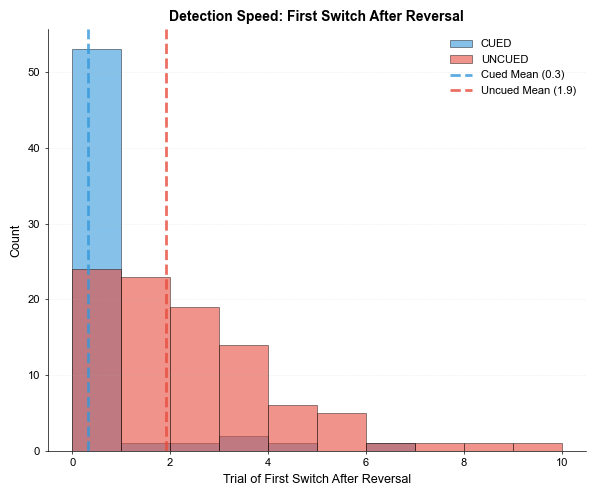


✓ Detection speed analysis complete!


In [23]:
# Panel D: Detection Speed - First Switch After Reversal
# ============================================================================

print("Calculating detection speed (first switch after reversal)...\n")

detection_data = []

for idx, trans in trans_df.iterrows():
    session_id = trans['session_id']
    to_block = trans['to_block']
    trans_type = trans['transition_type']
    animal = trans['animal']
    
    session_data = df[df['Session_ID'] == session_id]
    
    # Get trials from new block
    new_block_trials = session_data[session_data['Block'] == to_block].sort_values('Abs_Trial_Pos')
    
    if len(new_block_trials) >= 5:
        # Find first trial where they switch locations
        new_block_trials = new_block_trials[new_block_trials['PhysicalSwitch'].notna()]
        
        first_switch = new_block_trials[new_block_trials['PhysicalSwitch'] == 1]
        
        if len(first_switch) > 0:
            # Trial position of first switch relative to reversal
            first_switch_trial = first_switch.index[0] - new_block_trials.index[0]
        else:
            first_switch_trial = np.nan  # Never switched
        
        detection_data.append({
            'session_id': session_id,
            'animal': animal,
            'transition_type': trans_type,
            'first_switch_trial': first_switch_trial
        })

detect_df = pd.DataFrame(detection_data)
detect_df_clean = detect_df[detect_df['first_switch_trial'].notna()]
detect_df_clean = detect_df_clean[detect_df_clean['first_switch_trial'] <= 10]  # Within first 10 trials

print(f"Reversals with switch data: {len(detect_df_clean)}")

# Statistics
print("\n" + "="*70)
print("DETECTION SPEED (First Switch)")
print("="*70)

for trans_type in ['CUED', 'UNCUED']:
    data = detect_df_clean[detect_df_clean['transition_type'] == trans_type]['first_switch_trial']
    print(f"\n{trans_type}:")
    print(f"  Mean: {data.mean():.1f} trials")
    print(f"  Median: {data.median():.1f} trials")
    print(f"  n = {len(data)}")

# Statistical test
cued_detect = detect_df_clean[detect_df_clean['transition_type'] == 'CUED']['first_switch_trial']
uncued_detect = detect_df_clean[detect_df_clean['transition_type'] == 'UNCUED']['first_switch_trial']

u_stat, p_val = mannwhitneyu(cued_detect, uncued_detect, alternative='two-sided')
print(f"\nMann-Whitney U test:")
print(f"  U = {u_stat:.1f}, p = {p_val:.4f}")
print("="*70)

# Visualization
fig, ax = plt.subplots(figsize=(6, 5))

# Histogram comparison
bins = np.arange(0, 11)
ax.hist(cued_detect, bins=bins, alpha=0.6, color='#3498db', 
       edgecolor='black', linewidth=LINE_WIDTH, label='CUED')
ax.hist(uncued_detect, bins=bins, alpha=0.6, color='#e74c3c',
       edgecolor='black', linewidth=LINE_WIDTH, label='UNCUED')

# Add mean lines
ax.axvline(cued_detect.mean(), color='#3498db', linestyle='--', 
          linewidth=2, alpha=0.8, label=f'Cued Mean ({cued_detect.mean():.1f})')
ax.axvline(uncued_detect.mean(), color='#e74c3c', linestyle='--',
          linewidth=2, alpha=0.8, label=f'Uncued Mean ({uncued_detect.mean():.1f})')

ax.set_xlabel('Trial of First Switch After Reversal', fontsize=FONTSIZE+1)
ax.set_ylabel('Count', fontsize=FONTSIZE+1)
ax.set_title('Detection Speed: First Switch After Reversal', 
            fontsize=FONTSIZE+2, fontweight='bold')
ax.legend(fontsize=FONTSIZE, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Detection_Speed_Cued_vs_Uncued.svg'), dpi=300)
plt.show()

print("\n✓ Detection speed analysis complete!")

Creating trials to criterion by animal...



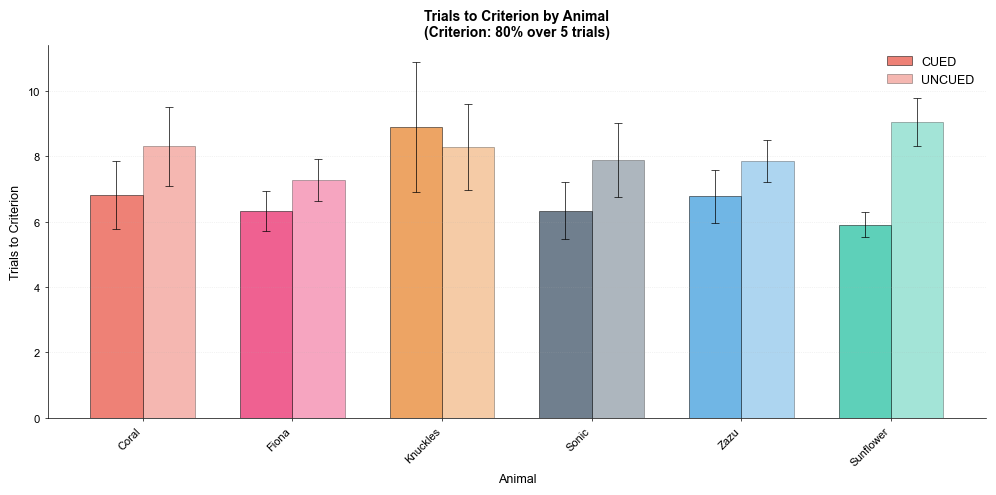


TRIALS TO CRITERION BY ANIMAL

Coral:
  CUED: 6.8 ± 1.0 (10 reversals)
  UNCUED: 8.3 ± 1.2 (13 reversals)

Fiona:
  CUED: 6.3 ± 0.6 (6 reversals)
  UNCUED: 7.3 ± 0.6 (15 reversals)

Knuckles:
  CUED: 8.9 ± 2.0 (9 reversals)
  UNCUED: 8.3 ± 1.3 (11 reversals)

Sonic:
  CUED: 6.3 ± 0.9 (9 reversals)
  UNCUED: 7.9 ± 1.1 (18 reversals)

Zazu:
  CUED: 6.8 ± 0.8 (13 reversals)
  UNCUED: 7.9 ± 0.6 (22 reversals)

Sunflower:
  CUED: 5.9 ± 0.4 (10 reversals)
  UNCUED: 9.1 ± 0.7 (19 reversals)

✓ By-animal analysis complete!


In [24]:
# Trials to Criterion by Animal (Cued vs Uncued)
# ============================================================================

print("Creating trials to criterion by animal...\n")

fig, ax = plt.subplots(figsize=(10, 5))

animals = sort_animals(ttc_df_clean['animal'].unique())
x_pos = np.arange(len(animals))
width = 0.35

# Calculate means and SEMs per animal
cued_means = []
cued_sems = []
uncued_means = []
uncued_sems = []

for animal in animals:
    animal_data = ttc_df_clean[ttc_df_clean['animal'] == animal]
    
    cued_data = animal_data[animal_data['transition_type'] == 'CUED']['trials_to_criterion']
    uncued_data = animal_data[animal_data['transition_type'] == 'UNCUED']['trials_to_criterion']
    
    cued_means.append(cued_data.mean() if len(cued_data) > 0 else np.nan)
    cued_sems.append(stats.sem(cued_data) if len(cued_data) > 1 else 0)
    uncued_means.append(uncued_data.mean() if len(uncued_data) > 0 else np.nan)
    uncued_sems.append(stats.sem(uncued_data) if len(uncued_data) > 1 else 0)

# Plot bars
bars1 = ax.bar(x_pos - width/2, cued_means, width,
              color=[ANIMAL_COLORS[a] for a in animals], alpha=0.7,
              edgecolor='black', linewidth=LINE_WIDTH, label='CUED')
ax.errorbar(x_pos - width/2, cued_means, yerr=cued_sems,
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH)

bars2 = ax.bar(x_pos + width/2, uncued_means, width,
              color=[ANIMAL_COLORS[a] for a in animals], alpha=0.4,
              edgecolor='black', linewidth=LINE_WIDTH, label='UNCUED')
ax.errorbar(x_pos + width/2, uncued_means, yerr=uncued_sems,
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH)

ax.set_xticks(x_pos)
ax.set_xticklabels(animals, rotation=45, ha='right')
ax.set_ylabel('Trials to Criterion', fontsize=FONTSIZE+1)
ax.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax.set_title(f'Trials to Criterion by Animal\n(Criterion: {int(CRITERION_ACCURACY*100)}% over {CRITERION_WINDOW} trials)',
            fontsize=FONTSIZE+2, fontweight='bold')
ax.legend(fontsize=FONTSIZE+1, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Trials_to_Criterion_by_Animal.svg'), dpi=300)
plt.show()

# Print summary
print("\n" + "="*70)
print("TRIALS TO CRITERION BY ANIMAL")
print("="*70)
for animal in animals:
    animal_data = ttc_df_clean[ttc_df_clean['animal'] == animal]
    cued = animal_data[animal_data['transition_type'] == 'CUED']['trials_to_criterion']
    uncued = animal_data[animal_data['transition_type'] == 'UNCUED']['trials_to_criterion']
    
    print(f"\n{animal}:")
    print(f"  CUED: {cued.mean():.1f} ± {stats.sem(cued):.1f} ({len(cued)} reversals)")
    print(f"  UNCUED: {uncued.mean():.1f} ± {stats.sem(uncued):.1f} ({len(uncued)} reversals)")
print("="*70)

print("\n✓ By-animal analysis complete!")

Creating trials to criterion by animal (Figure 1 style)...



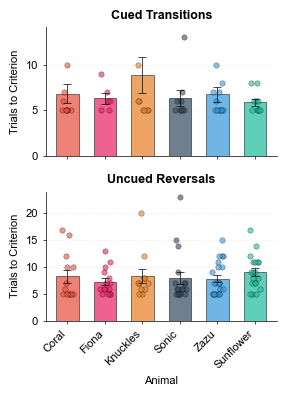


✓ By-animal trials to criterion figure complete!


In [25]:
# Trials to Criterion by Animal (Matching Figure 1 Style)
# ============================================================================

print("Creating trials to criterion by animal (Figure 1 style)...\n")

# Calculate summary per animal
ttc_summary = []

for animal in sort_animals(ttc_df_clean['animal'].unique()):
    animal_data = ttc_df_clean[ttc_df_clean['animal'] == animal]
    
    cued_data = animal_data[animal_data['transition_type'] == 'CUED']['trials_to_criterion']
    uncued_data = animal_data[animal_data['transition_type'] == 'UNCUED']['trials_to_criterion']
    
    ttc_summary.append({
        'animal': animal,
        'cued_mean': cued_data.mean() if len(cued_data) > 0 else np.nan,
        'cued_sem': stats.sem(cued_data) if len(cued_data) > 1 else 0,
        'uncued_mean': uncued_data.mean() if len(uncued_data) > 0 else np.nan,
        'uncued_sem': stats.sem(uncued_data) if len(uncued_data) > 1 else 0,
        'n_cued': len(cued_data),
        'n_uncued': len(uncued_data)
    })

ttc_summary_df = pd.DataFrame(ttc_summary)

# Create figure with TWO subplots (cued on top, uncued on bottom)
fig, axes = plt.subplots(2, 1, figsize=(3, 4), sharex=True)

x_pos = np.arange(len(ttc_summary_df))
width = 0.6

# ========================================================================
# Top panel: CUED
# ========================================================================

ax = axes[0]

bars = ax.bar(x_pos, ttc_summary_df['cued_mean'], width,
              color=[ANIMAL_COLORS[animal] for animal in ttc_summary_df['animal']],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

# Error bars
ax.errorbar(x_pos, ttc_summary_df['cued_mean'], yerr=ttc_summary_df['cued_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual data points
for idx, animal in enumerate(ttc_summary_df['animal']):
    animal_data = ttc_df_clean[(ttc_df_clean['animal'] == animal) & 
                                (ttc_df_clean['transition_type'] == 'CUED')]
    if len(animal_data) > 0:
        x_jitter = idx + np.random.uniform(-0.15, 0.15, size=len(animal_data))
        ax.scatter(x_jitter, animal_data['trials_to_criterion'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.6, edgecolor='black', linewidth=0.3, zorder=5)

ax.set_ylabel('Trials to Criterion', fontsize=FONTSIZE)
ax.set_title('Cued Transitions', fontsize=FONTSIZE+1, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)
ax.set_ylim(0, max(ttc_summary_df['cued_mean'].max(), ttc_summary_df['uncued_mean'].max()) + 5)

# ========================================================================
# Bottom panel: UNCUED
# ========================================================================

ax = axes[1]

bars = ax.bar(x_pos, ttc_summary_df['uncued_mean'], width,
              color=[ANIMAL_COLORS[animal] for animal in ttc_summary_df['animal']],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

# Error bars
ax.errorbar(x_pos, ttc_summary_df['uncued_mean'], yerr=ttc_summary_df['uncued_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual data points
for idx, animal in enumerate(ttc_summary_df['animal']):
    animal_data = ttc_df_clean[(ttc_df_clean['animal'] == animal) & 
                                (ttc_df_clean['transition_type'] == 'UNCUED')]
    if len(animal_data) > 0:
        x_jitter = idx + np.random.uniform(-0.15, 0.15, size=len(animal_data))
        ax.scatter(x_jitter, animal_data['trials_to_criterion'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.6, edgecolor='black', linewidth=0.3, zorder=5)

ax.set_xticks(x_pos)
ax.set_xticklabels(ttc_summary_df['animal'], rotation=45, ha='right')
ax.set_ylabel('Trials to Criterion', fontsize=FONTSIZE)
ax.set_xlabel('Animal', fontsize=FONTSIZE)
ax.set_title('Uncued Reversals', fontsize=FONTSIZE+1, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)
ax.set_ylim(0, max(ttc_summary_df['cued_mean'].max(), ttc_summary_df['uncued_mean'].max()) + 15)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, f'Trials_to_Criterion{CRITERION_ACCURACY}_window{CRITERION_WINDOW}_by_Animal.svg'), dpi=300)
plt.show()

print("\n✓ By-animal trials to criterion figure complete!")

Creating trials to criterion by animal (side-by-side)...



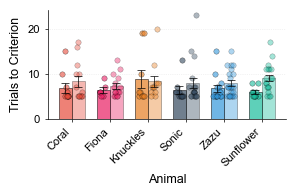


✓ Side-by-side trials to criterion figure complete!


In [26]:
# Trials to Criterion by Animal (Side-by-side bars)
# ============================================================================

print("Creating trials to criterion by animal (side-by-side)...\n")

fig, ax = plt.subplots(figsize=(3, 2))

x_pos = np.arange(len(ttc_summary_df))
width = 0.35

# Plot CUED bars (darker)
bars_cued = ax.bar(x_pos - width/2, ttc_summary_df['cued_mean'], width,
                   color=[ANIMAL_COLORS[animal] for animal in ttc_summary_df['animal']],
                   alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH,
                   label='Cued')

ax.errorbar(x_pos - width/2, ttc_summary_df['cued_mean'], 
           yerr=ttc_summary_df['cued_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Plot UNCUED bars (lighter)
bars_uncued = ax.bar(x_pos + width/2, ttc_summary_df['uncued_mean'], width,
                     color=[ANIMAL_COLORS[animal] for animal in ttc_summary_df['animal']],
                     alpha=0.4, edgecolor='black', linewidth=LINE_WIDTH,
                     label='Uncued')

ax.errorbar(x_pos + width/2, ttc_summary_df['uncued_mean'],
           yerr=ttc_summary_df['uncued_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual data points for CUED
for idx, animal in enumerate(ttc_summary_df['animal']):
    animal_cued = ttc_df_clean[(ttc_df_clean['animal'] == animal) & 
                                (ttc_df_clean['transition_type'] == 'CUED')]
    if len(animal_cued) > 0:
        x_jitter = (idx - width/2) + np.random.uniform(-0.1, 0.1, size=len(animal_cued))
        ax.scatter(x_jitter, animal_cued['trials_to_criterion'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.6, edgecolor='black', linewidth=0.3, zorder=5)

# Overlay individual data points for UNCUED
for idx, animal in enumerate(ttc_summary_df['animal']):
    animal_uncued = ttc_df_clean[(ttc_df_clean['animal'] == animal) & 
                                  (ttc_df_clean['transition_type'] == 'UNCUED')]
    if len(animal_uncued) > 0:
        x_jitter = (idx + width/2) + np.random.uniform(-0.1, 0.1, size=len(animal_uncued))
        ax.scatter(x_jitter, animal_uncued['trials_to_criterion'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.4, edgecolor='black', linewidth=0.3, zorder=5)

ax.set_xticks(x_pos)
ax.set_xticklabels(ttc_summary_df['animal'], rotation=45, ha='right')
ax.set_ylabel('Trials to Criterion', fontsize=FONTSIZE+1)
ax.set_xlabel('Animal', fontsize=FONTSIZE+1)
# ax.set_title(f'Trials to Criterion by Animal: Cued vs Uncued\n(Criterion: {int(CRITERION_ACCURACY*100)}% over {CRITERION_WINDOW} trials)',
#             fontsize=FONTSIZE+2, fontweight='bold')
# ax.legend(fontsize=FONTSIZE+1, frameon=False, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)
# ax.set_ylim(0, max(ttc_summary_df['cued_mean'].max(), ttc_summary_df['uncued_mean'].max()) + 8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, f'Trials_to_Criterion{CRITERION_ACCURACY}_window{CRITERION_WINDOW}_by_Animal_SideBySide.svg'), dpi=300)
plt.show()

print("\n✓ Side-by-side trials to criterion figure complete!")

Calculating late accuracy (final 5 trials) for cued vs uncued...

Blocks analyzed: 162


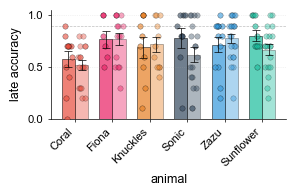


✓ Late accuracy figure complete!


In [27]:
# Late Accuracy by Animal: Cued vs Uncued (Final 5 trials)
# ============================================================================

print("Calculating late accuracy (final 5 trials) for cued vs uncued...\n")

LATE_WINDOW = 10  # Final 5 trials

late_accuracy_data = []

for idx, trans in trans_df.iterrows():
    session_id = trans['session_id']
    to_block = trans['to_block']
    trans_type = trans['transition_type']
    animal = trans['animal']
    
    session_data = df[df['Session_ID'] == session_id]
    
    # Get trials from new block
    new_block_trials = session_data[session_data['Block'] == to_block].sort_values('Abs_Trial_Pos')
    
    # Only analyze if block has enough trials
    if len(new_block_trials) >= LATE_WINDOW:
        # Get last 5 trials
        late_trials = new_block_trials.tail(LATE_WINDOW)
        late_acc = late_trials['Outcome'].mean()
        
        late_accuracy_data.append({
            'session_id': session_id,
            'animal': animal,
            'transition_type': trans_type,
            'late_accuracy': late_acc,
            'block_length': len(new_block_trials)
        })

late_acc_df = pd.DataFrame(late_accuracy_data)

print(f"Blocks analyzed: {len(late_acc_df)}")

# Calculate summary per animal
late_acc_summary = []

for animal in sort_animals(late_acc_df['animal'].unique()):
    animal_data = late_acc_df[late_acc_df['animal'] == animal]
    
    cued_data = animal_data[animal_data['transition_type'] == 'CUED']['late_accuracy']
    uncued_data = animal_data[animal_data['transition_type'] == 'UNCUED']['late_accuracy']
    
    late_acc_summary.append({
        'animal': animal,
        'cued_mean': cued_data.mean() if len(cued_data) > 0 else np.nan,
        'cued_sem': stats.sem(cued_data) if len(cued_data) > 1 else 0,
        'uncued_mean': uncued_data.mean() if len(uncued_data) > 0 else np.nan,
        'uncued_sem': stats.sem(uncued_data) if len(uncued_data) > 1 else 0,
        'n_cued': len(cued_data),
        'n_uncued': len(uncued_data)
    })

late_acc_summary_df = pd.DataFrame(late_acc_summary)

# Create figure
fig, ax = plt.subplots(figsize=(3, 2))

x_pos = np.arange(len(late_acc_summary_df))
width = 0.35

# Plot CUED bars (darker)
bars_cued = ax.bar(x_pos - width/2, late_acc_summary_df['cued_mean'], width,
                   color=[ANIMAL_COLORS[animal] for animal in late_acc_summary_df['animal']],
                   alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH,
                   label='Cued')

ax.errorbar(x_pos - width/2, late_acc_summary_df['cued_mean'], 
           yerr=late_acc_summary_df['cued_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Plot UNCUED bars (lighter)
bars_uncued = ax.bar(x_pos + width/2, late_acc_summary_df['uncued_mean'], width,
                     color=[ANIMAL_COLORS[animal] for animal in late_acc_summary_df['animal']],
                     alpha=0.4, edgecolor='black', linewidth=LINE_WIDTH,
                     label='Uncued')

ax.errorbar(x_pos + width/2, late_acc_summary_df['uncued_mean'],
           yerr=late_acc_summary_df['uncued_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual data points for CUED
for idx, animal in enumerate(late_acc_summary_df['animal']):
    animal_cued = late_acc_df[(late_acc_df['animal'] == animal) & 
                              (late_acc_df['transition_type'] == 'CUED')]
    if len(animal_cued) > 0:
        x_jitter = (idx - width/2) + np.random.uniform(-0.1, 0.1, size=len(animal_cued))
        ax.scatter(x_jitter, animal_cued['late_accuracy'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.6, edgecolor='black', linewidth=0.3, zorder=5)

# Overlay individual data points for UNCUED
for idx, animal in enumerate(late_acc_summary_df['animal']):
    animal_uncued = late_acc_df[(late_acc_df['animal'] == animal) & 
                                (late_acc_df['transition_type'] == 'UNCUED')]
    if len(animal_uncued) > 0:
        x_jitter = (idx + width/2) + np.random.uniform(-0.1, 0.1, size=len(animal_uncued))
        ax.scatter(x_jitter, animal_uncued['late_accuracy'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.4, edgecolor='black', linewidth=0.3, zorder=5)

# Reference line
ax.axhline(0.9, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(late_acc_summary_df['animal'], rotation=45, ha='right')
ax.set_ylabel('late accuracy', fontsize=FONTSIZE+1)
ax.set_xlabel('animal', fontsize=FONTSIZE+1)
# ax.set_title(f'Asymptotic Performance by Animal: Cued vs Uncued',
#             fontsize=FONTSIZE+2, fontweight='bold')
# ax.legend(fontsize=FONTSIZE+1, frameon=False, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)
# ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Late_Accuracy_by_Animal_SideBySide.svg'), dpi=300)
plt.show()

print("\n✓ Late accuracy figure complete!")

Finding good exemplar session with both cued and uncued reversals...

Using exemplar session: 2023-08-11_20230811_Knuckles_Reversal1.1
  Animal: Knuckles
  Total trials: 283
  Blocks: 4


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_49974/1568754170.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


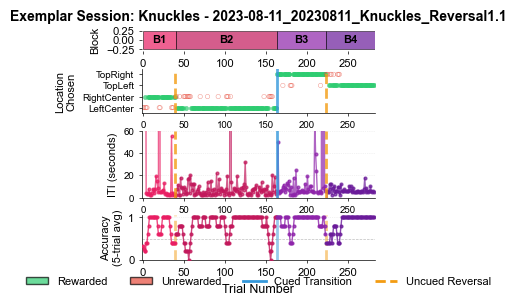


✓ Exemplar session figure created!


In [30]:
# Exemplar Session: Cued vs Uncued Reversals (Complete Rewrite)
# ============================================================================

print("Finding good exemplar session with both cued and uncued reversals...\n")

# # Define nice block colors
BLOCK_COLORS = ['#e91e63', '#c2185b', '#8e24aa', '#6a1b9a'] #['#bdc3c7', '#95a5a6', '#7f8c8d', '#2c3e50'] # trying grey series 
# BLOCK_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', 
#                 '#1abc9c', '#e67e22', '#34495e', '#95a5a6', '#d35400']

# Find a session with both transition types
sessions_with_both = trans_df.groupby('session_id')['transition_type'].apply(
    lambda x: ('CUED' in x.values) and ('UNCUED' in x.values)
)
good_sessions = sessions_with_both[sessions_with_both].index

if len(good_sessions) > 0:
    example_session_id = good_sessions[0]
    
    print(f"Using exemplar session: {example_session_id}")
    
    # Get session data
    session_data = df[df['Session_ID'] == example_session_id].sort_values('Abs_Trial_Pos').reset_index(drop=True)
    session_trans = trans_df[trans_df['session_id'] == example_session_id]
    
    animal = session_data['Animal_Name'].iloc[0]
    
    print(f"  Animal: {animal}")
    print(f"  Total trials: {len(session_data)}")
    print(f"  Blocks: {session_data['Block'].nunique()}")
    
    # Calculate ITI
    session_data['Prev_StartTime'] = session_data['AbsoluteTrialStartTime'].shift(1)
    session_data['ITI_calc'] = (session_data['AbsoluteTrialStartTime'] - session_data['Prev_StartTime']) / 1000
    
    # Assign continuous trial number
    session_data['continuous_trial'] = range(len(session_data))
    
    # Create figure
    fig = plt.figure(figsize=(3, 3))
    gs = fig.add_gridspec(4, 1, hspace=0.4, height_ratios=[0.5, 1, 1.5, 1])
    
    # ====================================================================
    # Panel A: Block Structure
    # ====================================================================
    
    ax1 = fig.add_subplot(gs[0])
    
    blocks = sorted(session_data['Block'].unique())
    for idx, block in enumerate(blocks):
        block_trials = session_data[session_data['Block'] == block]
        start = block_trials['continuous_trial'].min()
        end = block_trials['continuous_trial'].max()
        
        block_color = BLOCK_COLORS[idx % len(BLOCK_COLORS)]
        
        ax1.barh(0, end - start + 1, left=start, height=0.5,
                color=block_color, edgecolor='black', linewidth=0.5, alpha=0.7)
        ax1.text((start + end) / 2, 0, f'B{block}',
                ha='center', va='center', fontsize=FONTSIZE, fontweight='bold')
    
    ax1.set_xlim(-1, len(session_data))
    ax1.set_ylim(-0.3, 0.3)
    # ax1.set_yticks([])
    # ax1.set_xticks([])
    ax1.set_ylabel('Block', fontsize=FONTSIZE)
    ax1.set_title(f'Exemplar Session: {animal} - {example_session_id}',
                 fontsize=FONTSIZE+2, fontweight='bold')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    
    # ====================================================================
    # Panel B: Physical Choice (colored by outcome)
    # ====================================================================
    
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    
    # Map locations to y-values
    unique_locs = sorted(session_data['PhysicalChoice'].dropna().unique())
    loc_to_y = {loc: i for i, loc in enumerate(unique_locs)}
    
    # # Plot choices colored by outcome
    # for idx, trial in session_data.iterrows():
    #     if pd.notna(trial['PhysicalChoice']):
    #         y_val = loc_to_y[trial['PhysicalChoice']]
    #         color = '#2ecc71' if trial['Outcome'] == 1 else '#e74c3c'
    #         fill_color = '#2ecc71' if trial['Outcome'] == 1 else None
    #         ax2.scatter(trial['continuous_trial'], y_val, s=10, color=color,marker='o',markerfacecolor=fill_color,
    #                    alpha=0.7, edgecolor='black', linewidth=0.3)
    # Plot choices colored by outcome
    for idx, trial in session_data.iterrows():
        if pd.notna(trial['PhysicalChoice']):
            y_val = loc_to_y[trial['PhysicalChoice']]

            if trial['Outcome'] == 1:
                face_color = '#2ecc71'   # green fill
            else:
                face_color = 'none'      # hollow

            edge_color = '#2ecc71' if trial['Outcome'] == 1 else '#e74c3c'

            ax2.scatter(
                trial['continuous_trial'],
                y_val,
                s=10,
                marker='o',
                facecolors=face_color,
                edgecolors=edge_color,
                alpha=0.7,
                linewidth=0.3
            )
    # Mark transitions
    for _, trans in session_trans.iterrows():
        trans_block = session_data[session_data['Block'] == trans['to_block']]
        if len(trans_block) > 0:
            trans_pos = trans_block['continuous_trial'].iloc[0]
            color = '#3498db' if trans['transition_type'] == 'CUED' else '#f39c12'
            linestyle = '-' if trans['transition_type'] == 'CUED' else '--'
            ax2.axvline(trans_pos - 0.5, color=color, linestyle=linestyle,
                       linewidth=2, alpha=0.8, zorder=10)
    
    ax2.set_yticks(range(len(unique_locs)))
    ax2.set_yticklabels(unique_locs, fontsize=FONTSIZE-1)
    ax2.set_ylabel('Location\nChosen', fontsize=FONTSIZE)
    ax2.set_ylim(-0.5, len(unique_locs) - 0.5)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)
    
    # ====================================================================
    # Panel C: Inter-Trial Interval (colored by block)
    # ====================================================================
    
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    
    # Mark transitions
    for _, trans in session_trans.iterrows():
        trans_block = session_data[session_data['Block'] == trans['to_block']]
        if len(trans_block) > 0:
            trans_pos = trans_block['continuous_trial'].iloc[0]
            color = '#3498db' if trans['transition_type'] == 'CUED' else '#f39c12'
            linestyle = '-' if trans['transition_type'] == 'CUED' else '--'
            ax3.axvline(trans_pos - 0.5, color=color, linestyle=linestyle,
                       linewidth=2, alpha=0.8, zorder=10)
    
    # Plot ITI colored by block
    blocks = sorted(session_data['Block'].unique())
    for idx, block in enumerate(blocks):
        block_trials = session_data[session_data['Block'] == block]
        block_color = BLOCK_COLORS[idx % len(BLOCK_COLORS)]
        
        ax3.plot(block_trials['continuous_trial'], block_trials['ITI_calc'],
                'o-', color=block_color, linewidth=1, markersize=2, alpha=0.7)
    
    ax3.set_ylabel('ITI (seconds)', fontsize=FONTSIZE)
    ax3.set_ylim(0, min(session_data['ITI_calc'].max() * 1.2, 60))
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax3.tick_params(axis='both', labelsize=FONTSIZE-1, length=TICK_LENGTH)
    
    # ====================================================================
    # Panel D: Rolling Accuracy (colored by block)
    # ====================================================================
    
    ax4 = fig.add_subplot(gs[3], sharex=ax1)
    
    # Calculate rolling average
    window = 5
    session_data['rolling_accuracy'] = session_data['Outcome'].rolling(
        window=window, min_periods=1, center=True).mean()
    
    # Mark transitions
    for _, trans in session_trans.iterrows():
        trans_block = session_data[session_data['Block'] == trans['to_block']]
        if len(trans_block) > 0:
            trans_pos = trans_block['continuous_trial'].iloc[0]
            color = '#3498db' if trans['transition_type'] == 'CUED' else '#f39c12'
            linestyle = '-' if trans['transition_type'] == 'CUED' else '--'
            ax4.axvline(trans_pos - 0.5, color=color, linestyle=linestyle,
                       linewidth=2, alpha=0.5, zorder=1)
    
    # Plot rolling accuracy colored by block
    blocks = sorted(session_data['Block'].unique())
    for idx, block in enumerate(blocks):
        block_trials = session_data[session_data['Block'] == block]
        block_color = BLOCK_COLORS[idx % len(BLOCK_COLORS)]
        
        ax4.plot(block_trials['continuous_trial'], block_trials['rolling_accuracy'],
                'o-', color=block_color, linewidth=1, markersize=2, alpha=0.8, zorder=5)
    
    ax4.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
    ax4.set_ylabel(f'Accuracy\n({window}-trial avg)', fontsize=FONTSIZE)
    ax4.set_xlabel('Trial Number', fontsize=FONTSIZE+1)
    ax4.set_ylim(0, 1.05)
    ax4.spines['top'].set_visible(False)
    ax4.spines['right'].set_visible(False)
    ax4.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax4.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Rewarded', alpha=0.7, edgecolor='black'),
        Patch(facecolor='#e74c3c', label='Unrewarded', alpha=0.7, edgecolor='black'),
        plt.Line2D([0], [0], color='#3498db', linewidth=2, label='Cued Transition'),
        plt.Line2D([0], [0], color='#f39c12', linewidth=2, linestyle='--', label='Uncued Reversal')
    ]
    ax4.legend(handles=legend_elements, fontsize=FONTSIZE, frameon=False,
              loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_PATH, 'Exemplar_Session_Cued_vs_Uncued.svg'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Exemplar session figure created!")
    
else:
    print("⚠️ No sessions found with both cued and uncued transitions")

In [92]:
# For column StimuliChosen encode TargetA as 1 and TargetB as 0
df['test_choice'] = df['StimuliChosen'].map({'TargetA': 1, 'TargetB': 0})
df['test_outcome'] = df['Reward'].map({'Rewarded': 1, 'Unrewarded': 0})

# Add history columns to marmoset Bandit data

In [93]:
# Add history columns to marmoset Bandit data
# ============================================================================

def add_history_cols_marmoset(df, N):
    """
    Add choice/outcome history columns to marmoset reversal data.
    
    INPUTS:
        - df (pandas DataFrame): marmoset behavior dataset
        - N (int): number of trials prior to current trial for history sequence
    
    OUTPUTS:
        - df (pandas DataFrame): with additional columns:
            - 'decision_seq': string of previous N decisions (PhysicalChoice: 0 or 1)
            - 'reward_seq': string of previous N rewards (Outcome: 0 or 1)
            - 'history': encoded choice/outcome (symmetrical)
            - 'RL_history': encoded choice/outcome (raw directionality)
    """
    from numpy.lib.stride_tricks import sliding_window_view
    
    # Initialize columns
    df['decision_seq'] = pd.Series(np.nan, index=df.index).astype(object)
    df['reward_seq'] = pd.Series(np.nan, index=df.index).astype(object)
    df['history'] = pd.Series(np.nan, index=df.index).astype(object)
    df['RL_history'] = pd.Series(np.nan, index=df.index).astype(object)
    
    # Reset index
    df = df.reset_index(drop=True)
    
    # Process each session separately
    for session in df['Session_ID'].unique():
        d = df.loc[df['Session_ID'] == session].copy()
        
        # Skip if not enough trials
        if len(d) <= N:
            continue
        
        # Convert PhysicalChoice and Outcome to int for sequences
        # PhysicalChoice: 0 or 1 (which option chosen)
        # Outcome: 0 or 1 (unrewarded or rewarded)
        decision_arr = d['test_choice'].fillna(0).astype('int').values
        reward_arr = d['test_outcome'].fillna(0).astype('int').values
        
        # Generate sequences using sliding window
        decision_sequences = list(map(list_to_str, sliding_window_view(decision_arr, N)))[:-1]
        reward_sequences = list(map(list_to_str, sliding_window_view(reward_arr, N)))[:-1]
        
        # Assign to rows starting at index N
        df.loc[d.index.values[N:], 'decision_seq'] = decision_sequences
        df.loc[d.index.values[N:], 'reward_seq'] = reward_sequences
        
        # Generate encoded history columns
        df.loc[d.index.values[N:], 'history'] = df.loc[d.index.values[N:]].apply(
            encode_as_ab, args=([True]), axis=1
        )
        df.loc[d.index.values[N:], 'RL_history'] = df.loc[d.index.values[N:]].apply(
            encode_as_ab, args=([False]), axis=1
        )
    
    return df

def list_to_str(seq):
    """Convert list of ints/floats to string"""
    seq = [str(el) for el in seq]
    return ''.join(seq)

def encode_as_ab(row, symm):
    """
    Convert choice/outcome history to character code
    INPUTS:
        - row: DataFrame row with 'decision_seq' and 'reward_seq'
        - symm (bool): if True, symmetrical A/B encoding; if False, raw encoding
    OUTPUTS:
        - string encoding each choice/outcome combination
    """
    if int(row.decision_seq[0]) & symm:  # First choice = 1 → A
        mapping = {('0','0'): 'b', ('0','1'): 'B', ('1','0'): 'a', ('1','1'): 'A'} 
    elif (int(row.decision_seq[0])==0) & symm:  # First choice = 0 → A    
        mapping = {('0','0'): 'a', ('0','1'): 'A', ('1','0'): 'b', ('1','1'): 'B'} 
    else:  # Raw mapping
        mapping = {('0','0'): 'r', ('0','1'): 'R', ('1','0'): 'l', ('1','1'): 'L'} 

    return ''.join([mapping[(c,r)] for c,r in zip(row.decision_seq, row.reward_seq)])

# Apply to your 2-ABT data
N = 3  # History window
df_hist = add_history_cols_marmoset(df, N)

print(f"\n✓ History columns added (N={N})")
print(f"Sample decision sequences: {df_hist['decision_seq'].dropna().head()}")
print(f"Sample reward sequences: {df_hist['reward_seq'].dropna().head()}")
print(f"Sample history encoding: {df_hist['history'].dropna().head()}")


✓ History columns added (N=3)
Sample decision sequences: 3    001
4    010
5    100
6    000
7    001
Name: decision_seq, dtype: object
Sample reward sequences: 3    001
4    010
5    100
6    000
7    001
Name: reward_seq, dtype: object
Sample history encoding: 3    aaB
4    aBa
5    Abb
6    aaa
7    aaB
Name: history, dtype: object


In [102]:
df.prob_Condition.unique()

array(['100-0'], dtype=object)

Calculating P(Switch) by reward sequence...

Trials with 3-trial history: 11,325

Reward sequences found: 8

P(Switch) by reward sequence (sorted):
  reward_seq  p_switch  n_trials
7        111  0.119758      6206
3        011  0.168719       920
1        001  0.200506       760
5        101  0.219149       408
2        010  0.341190       262
6        110  0.354042       918
4        100  0.414972       773
0        000  0.493868      1074


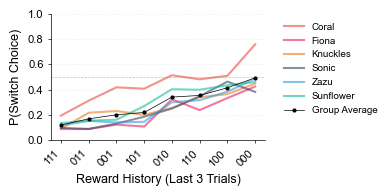


✓ P(Switch) analysis complete!


In [103]:
# ============================================================================
# P(Switch) by Reward History
# ============================================================================

print("Calculating P(Switch) by reward sequence...\n")

PROB_CONDITION = df_hist.prob_Condition.unique()[0]
# Filter out rows without history
df_with_history = df_hist[df_hist['reward_seq'].notna()].copy()

print(f"Trials with {N}-trial history: {len(df_with_history):,}")

# Calculate P(Switch) for each reward sequence and animal
switch_by_history = df_with_history.groupby(['Animal_Name', 'reward_seq']).agg({
    'PhysicalSwitch': ['mean', 'sem', 'count']
}).reset_index()

switch_by_history.columns = ['Animal_Name', 'reward_seq', 'p_switch', 'sem', 'n_trials']

# Calculate overall P(Switch) across animals for each reward sequence
overall_switch = switch_by_history.groupby('reward_seq').agg({
    'p_switch': 'mean',
    'n_trials': 'sum'
}).reset_index()

overall_switch = overall_switch.sort_values('p_switch')

print(f"\nReward sequences found: {len(overall_switch)}")
print("\nP(Switch) by reward sequence (sorted):")
print(overall_switch)

# ============================================================================
# Plot P(Switch) by Reward Sequence
# ============================================================================

fig, ax = plt.subplots(figsize=(4, 2))

# Sort reward sequences by overall P(Switch)
sorted_seqs = overall_switch['reward_seq'].values

# Plot individual animals
for animal in sort_animals(switch_by_history['Animal_Name'].unique()):
    animal_data = switch_by_history[switch_by_history['Animal_Name'] == animal]
    
    # Reindex to match sorted sequences
    animal_data = animal_data.set_index('reward_seq').reindex(sorted_seqs).reset_index()
    
    ax.plot(range(len(sorted_seqs)), animal_data['p_switch'],
           '-', color=ANIMAL_COLORS[animal], alpha=0.6, linewidth=1.5,
           markersize=4, label=animal)

# Plot overall average
overall_sorted = overall_switch.set_index('reward_seq').reindex(sorted_seqs).reset_index()
ax.plot(range(len(sorted_seqs)), overall_sorted['p_switch'],
       'o-', color='black', linewidth=LINE_WIDTH, markersize=2,
       label='Group Average', zorder=10)

# Formatting
ax.set_xticks(range(len(sorted_seqs)))
ax.set_xticklabels(sorted_seqs, rotation=45, ha='right', fontsize=FONTSIZE-1)
ax.set_xlabel('Reward History (Last 3 Trials)', fontsize=FONTSIZE+1)
ax.set_ylabel('P(Switch Choice)', fontsize=FONTSIZE+1)

ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax.legend(fontsize=FONTSIZE-1, frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH_ALL_PROBS, f'Switch_by_RewardHistory_{PROB_CONDITION}.svg'), 
           dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ P(Switch) analysis complete!")

Calculating P(Switch) by reward sequence...

Trials with 3-trial history: 11,325

Reward sequences found: 8

P(Switch) by reward sequence (sorted):
   history  p_switch  n_trials
0      AAA  0.119758      6206
9      aBB  0.165566       917
12     aaB  0.193049       753
5      AbA  0.212652       403
10     aBa  0.330744       254
2      AAb  0.352472       916
6      Abb  0.410674       768
13     aaa  0.493868      1074


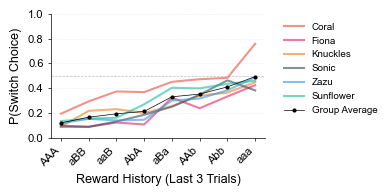


✓ P(Switch) analysis complete!


In [106]:
# ============================================================================
# P(Switch) by Decision History
# ============================================================================

print("Calculating P(Switch) by reward sequence...\n")

PROB_CONDITION = df_hist.prob_Condition.unique()[0]
# Filter out rows without history
feature_col = 'history'
df_with_history = df_hist[df_hist[feature_col].notna()].copy()

print(f"Trials with {N}-trial history: {len(df_with_history):,}")

# Calculate P(Switch) for each reward sequence and animal
switch_by_history = df_with_history.groupby(['Animal_Name', feature_col]).agg({
    'PhysicalSwitch': ['mean', 'sem', 'count']
}).reset_index()

switch_by_history.columns = ['Animal_Name', feature_col, 'p_switch', 'sem', 'n_trials']

# Calculate overall P(Switch) across animals for each reward sequence
overall_switch = switch_by_history.groupby(feature_col).agg({
    'p_switch': 'mean',
    'n_trials': 'sum'
}).reset_index()

# Filter out sequences with fewer than 100 trials
overall_switch = overall_switch[overall_switch['n_trials'] >= 100]
overall_switch = overall_switch.sort_values('p_switch')

print(f"\nReward sequences found: {len(overall_switch)}")
print("\nP(Switch) by reward sequence (sorted):")
print(overall_switch)

# ============================================================================
# Plot P(Switch) by Reward Sequence
# ============================================================================

fig, ax = plt.subplots(figsize=(4, 2))

# Sort reward sequences by overall P(Switch)
sorted_seqs = overall_switch[feature_col].values

# Plot individual animals
for animal in sort_animals(switch_by_history['Animal_Name'].unique()):
    animal_data = switch_by_history[switch_by_history['Animal_Name'] == animal]
    
    # Reindex to match sorted sequences
    animal_data = animal_data.set_index(feature_col).reindex(sorted_seqs).reset_index()
    
    ax.plot(range(len(sorted_seqs)), animal_data['p_switch'],
           '-', color=ANIMAL_COLORS[animal], alpha=0.6, linewidth=1.5,
           markersize=4, label=animal)

# Plot overall average
overall_sorted = overall_switch.set_index(feature_col).reindex(sorted_seqs).reset_index()
ax.plot(range(len(sorted_seqs)), overall_sorted['p_switch'],
       'o-', color='black', linewidth=LINE_WIDTH, markersize=2,
       label='Group Average', zorder=10)

# Formatting
ax.set_xticks(range(len(sorted_seqs)))
ax.set_xticklabels(sorted_seqs, rotation=45, ha='right', fontsize=FONTSIZE-1)
ax.set_xlabel('Reward History (Last 3 Trials)', fontsize=FONTSIZE+1)
ax.set_ylabel('P(Switch Choice)', fontsize=FONTSIZE+1)

ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
ax.legend(fontsize=FONTSIZE-1, frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH_ALL_PROBS, f'Switch_by_{feature_col}_{PROB_CONDITION}.svg'), 
           dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ P(Switch) analysis complete!")

Calculating Win-Stay / Lose-Shift rates...

Trials with previous outcome: 11,378

Win-Stay / Lose-Shift summary:
      animal  win_stay_mean  win_stay_sem  lose_shift_mean  lose_shift_sem  \
0      Coral       0.722924      0.009190         0.547789        0.043140   
1      Fiona       0.909891      0.018793         0.336156        0.064112   
2   Knuckles       0.883355      0.021199         0.395091        0.030535   
3      Sonic       0.896311      0.010873         0.377933        0.024452   
4       Zazu       0.846102      0.029442         0.436741        0.036663   
5  Sunflower       0.848289      0.014206         0.433676        0.021155   

   n_sessions  
0          10  
1           7  
2           5  
3           9  
4          12  
5          10  


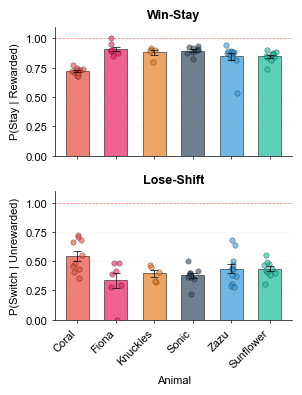


✓ Win-Stay/Lose-Shift figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/Reversal_All_Probs/WinStay_LoseShift_100-0.svg

GROUP STATISTICS
Win-Stay: 0.851 ± 0.017
Lose-Shift: 0.421 ± 0.037


In [123]:
# ============================================================================
# Analysis 2: Win-Stay / Lose-Shift Rates (Matching Style)
# ============================================================================

print("Calculating Win-Stay / Lose-Shift rates...\n")

# Filter for trials with valid switch info
df_wsls = df_hist[df_hist['PhysicalSwitch'].notna()].copy()

# Create previous outcome column
df_wsls = df_wsls.sort_values(['Session_ID', 'Block', 'Trial']).reset_index(drop=True)
df_wsls['Prev_Outcome'] = df_wsls.groupby('Session_ID')['Outcome'].shift(1)

# Remove first trial of each session
df_wsls = df_wsls[df_wsls['Prev_Outcome'].notna()].copy()

print(f"Trials with previous outcome: {len(df_wsls):,}")

# Calculate rates per animal per session
wsls_sessions = []

for session_id in df_wsls['Session_ID'].unique():
    session_data = df_wsls[df_wsls['Session_ID'] == session_id]
    animal = session_data['Animal_Name'].iloc[0]
    
    # Win trials (previous trial rewarded)
    win_trials = session_data[session_data['Prev_Outcome'] == 1]
    win_stay_rate = (win_trials['PhysicalSwitch'] == 0).mean() if len(win_trials) > 0 else np.nan
    
    # Lose trials (previous trial unrewarded)
    lose_trials = session_data[session_data['Prev_Outcome'] == 0]
    lose_shift_rate = (lose_trials['PhysicalSwitch'] == 1).mean() if len(lose_trials) > 0 else np.nan
    
    wsls_sessions.append({
        'session_id': session_id,
        'animal': animal,
        'win_stay': win_stay_rate,
        'lose_shift': lose_shift_rate,
        'n_win': len(win_trials),
        'n_lose': len(lose_trials)
    })

wsls_sessions_df = pd.DataFrame(wsls_sessions)

# Calculate summary per animal
wsls_summary = []

for animal in sort_animals(wsls_sessions_df['animal'].unique()):
    animal_data = wsls_sessions_df[wsls_sessions_df['animal'] == animal]
    
    wsls_summary.append({
        'animal': animal,
        'win_stay_mean': animal_data['win_stay'].mean(),
        'win_stay_sem': stats.sem(animal_data['win_stay'].dropna()),
        'lose_shift_mean': animal_data['lose_shift'].mean(),
        'lose_shift_sem': stats.sem(animal_data['lose_shift'].dropna()),
        'n_sessions': len(animal_data)
    })

wsls_summary_df = pd.DataFrame(wsls_summary)

print("\nWin-Stay / Lose-Shift summary:")
print(wsls_summary_df)

# Create figure with TWO subplots (Win-Stay on top, Lose-Shift on bottom)
fig, axes = plt.subplots(2, 1, figsize=(3, 4), sharex=True)

x_pos = np.arange(len(wsls_summary_df))
width = 0.6

# ========================================================================
# Top panel: WIN-STAY
# ========================================================================

ax = axes[0]

bars = ax.bar(x_pos, wsls_summary_df['win_stay_mean'], width,
              color=[ANIMAL_COLORS[animal] for animal in wsls_summary_df['animal']],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

# Error bars
ax.errorbar(x_pos, wsls_summary_df['win_stay_mean'], yerr=wsls_summary_df['win_stay_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual session points
for idx, animal in enumerate(wsls_summary_df['animal']):
    animal_sessions = wsls_sessions_df[wsls_sessions_df['animal'] == animal]
    if len(animal_sessions) > 0:
        x_jitter = idx + np.random.uniform(-0.15, 0.15, size=len(animal_sessions))
        ax.scatter(x_jitter, animal_sessions['win_stay'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.6, edgecolor='black', linewidth=0.3, zorder=5)

# Reference line at 1.0 (deterministic)
ax.axhline(1.0, color='red', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)

ax.set_ylabel('P(Stay | Rewarded)', fontsize=FONTSIZE)
ax.set_title('Win-Stay', fontsize=FONTSIZE+1, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# ========================================================================
# Bottom panel: LOSE-SHIFT
# ========================================================================

ax = axes[1]

bars = ax.bar(x_pos, wsls_summary_df['lose_shift_mean'], width,
              color=[ANIMAL_COLORS[animal] for animal in wsls_summary_df['animal']],
              alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH)

# Error bars
ax.errorbar(x_pos, wsls_summary_df['lose_shift_mean'], yerr=wsls_summary_df['lose_shift_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual session points
for idx, animal in enumerate(wsls_summary_df['animal']):
    animal_sessions = wsls_sessions_df[wsls_sessions_df['animal'] == animal]
    if len(animal_sessions) > 0:
        x_jitter = idx + np.random.uniform(-0.15, 0.15, size=len(animal_sessions))
        ax.scatter(x_jitter, animal_sessions['lose_shift'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.6, edgecolor='black', linewidth=0.3, zorder=5)

# Reference line at 1.0 (deterministic)
ax.axhline(1.0, color='red', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(wsls_summary_df['animal'], rotation=45, ha='right')
ax.set_ylabel('P(Switch | Unrewarded)', fontsize=FONTSIZE)
ax.set_xlabel('Animal', fontsize=FONTSIZE)
ax.set_title('Lose-Shift', fontsize=FONTSIZE+1, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH_ALL_PROBS, f'WinStay_LoseShift_{PROB_CONDITION}.svg'), 
           dpi=300)
plt.show()

print(f"\n✓ Win-Stay/Lose-Shift figure saved to:")
print(f"  {FIGURE_PATH_ALL_PROBS}/WinStay_LoseShift_{PROB_CONDITION}.svg")

# Print group statistics
print("\n" + "="*70)
print("GROUP STATISTICS")
print("="*70)
print(f"Win-Stay: {wsls_summary_df['win_stay_mean'].mean():.3f} ± {wsls_summary_df['win_stay_sem'].mean():.3f}")
print(f"Lose-Shift: {wsls_summary_df['lose_shift_mean'].mean():.3f} ± {wsls_summary_df['lose_shift_sem'].mean():.3f}")
print("="*70)

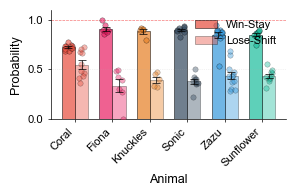


✓ Win-Stay/Lose-Shift figure saved to:
  /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/Reversal_All_Probs/WinStay_LoseShift_100-0.svg


In [127]:
# Create figure with side-by-side bars
fig, ax = plt.subplots(figsize=(3, 2))

x_pos = np.arange(len(wsls_summary_df))
width = 0.35

# ========================================================================
# Win-Stay bars (darker)
# ========================================================================

bars_ws = ax.bar(x_pos - width/2, wsls_summary_df['win_stay_mean'], width,
                 color=[ANIMAL_COLORS[animal] for animal in wsls_summary_df['animal']],
                 alpha=0.7, edgecolor='black', linewidth=LINE_WIDTH,
                 label='Win-Stay')

ax.errorbar(x_pos - width/2, wsls_summary_df['win_stay_mean'], 
           yerr=wsls_summary_df['win_stay_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual session points for Win-Stay
for idx, animal in enumerate(wsls_summary_df['animal']):
    animal_sessions = wsls_sessions_df_filtered[wsls_sessions_df_filtered['animal'] == animal]
    if len(animal_sessions) > 0:
        x_jitter = (idx - width/2) + np.random.uniform(-0.1, 0.1, size=len(animal_sessions))
        ax.scatter(x_jitter, animal_sessions['win_stay'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.6, edgecolor='black', linewidth=0.3, zorder=5)

# ========================================================================
# Lose-Shift bars (lighter)
# ========================================================================

bars_ls = ax.bar(x_pos + width/2, wsls_summary_df['lose_shift_mean'], width,
                 color=[ANIMAL_COLORS[animal] for animal in wsls_summary_df['animal']],
                 alpha=0.4, edgecolor='black', linewidth=LINE_WIDTH,
                 label='Lose-Shift')

ax.errorbar(x_pos + width/2, wsls_summary_df['lose_shift_mean'],
           yerr=wsls_summary_df['lose_shift_sem'],
           fmt='none', color='black', linewidth=LINE_WIDTH,
           capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual session points for Lose-Shift
for idx, animal in enumerate(wsls_summary_df['animal']):
    animal_sessions = wsls_sessions_df_filtered[wsls_sessions_df_filtered['animal'] == animal]
    if len(animal_sessions) > 0:
        x_jitter = (idx + width/2) + np.random.uniform(-0.1, 0.1, size=len(animal_sessions))
        ax.scatter(x_jitter, animal_sessions['lose_shift'],
                  s=15, color=ANIMAL_COLORS[animal],
                  alpha=0.4, edgecolor='black', linewidth=0.3, zorder=5)

# Reference line at 1.0 (deterministic)
ax.axhline(1.0, color='red', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)

ax.set_xticks(x_pos)
ax.set_xticklabels(wsls_summary_df['animal'], rotation=45, ha='right')
ax.set_ylabel('Probability', fontsize=FONTSIZE+1)
ax.set_xlabel('Animal', fontsize=FONTSIZE+1)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=FONTSIZE, frameon=False, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH_ALL_PROBS, f'WinStay_LoseShift_{PROB_CONDITION}.svg'), 
           dpi=300)
plt.show()

print(f"\n✓ Win-Stay/Lose-Shift figure saved to:")
print(f"  {FIGURE_PATH_ALL_PROBS}/WinStay_LoseShift_{PROB_CONDITION}.svg")

In [124]:
# After creating wsls_sessions_df, add filtering:

# Check for suspicious sessions (all win-stay or no lose-shift)
print("\nChecking for edge case sessions...")

suspicious = wsls_sessions_df[
    (wsls_sessions_df['win_stay'] == 1.0) | 
    (wsls_sessions_df['lose_shift'] == 0.0) |
    (wsls_sessions_df['n_win'] < 10) |
    (wsls_sessions_df['n_lose'] < 10)
]

print(f"Found {len(suspicious)} sessions with potential issues:")
for _, sess in suspicious.iterrows():
    print(f"  {sess['animal']} - {sess['session_id']}: "
          f"WS={sess['win_stay']:.2f} (n={sess['n_win']}), "
          f"LS={sess['lose_shift']:.2f} (n={sess['n_lose']})")

# Filter out sessions with too few trials in either category
MIN_TRIALS = 10
wsls_sessions_df_filtered = wsls_sessions_df[
    (wsls_sessions_df['n_win'] >= MIN_TRIALS) & 
    (wsls_sessions_df['n_lose'] >= MIN_TRIALS)
].copy()

print(f"\nFiltered from {len(wsls_sessions_df)} to {len(wsls_sessions_df_filtered)} sessions")
print(f"  (removed sessions with <{MIN_TRIALS} win or lose trials)")

# Then use wsls_sessions_df_filtered instead of wsls_sessions_df for the rest


Checking for edge case sessions...
Found 1 sessions with potential issues:
  Fiona - 2024-02-22_240222_FIona_VDT_NoInitiation_100_Conflict_Reversal1.1: WS=1.00 (n=246), LS=0.00 (n=84)

Filtered from 53 to 53 sessions
  (removed sessions with <10 win or lose trials)


Analyzing what precedes breaks in behavior...

ITI threshold (75th percentile): 7.5 seconds

Total trials analyzed: 11,378
Trials with breaks (ITI > 7.5s): 2,808 (24.7%)

BREAKS FOLLOWING WINS vs LOSSES

P(break | previous outcome):
               p_break  n_breaks  n_trials
prev_outcome                              
0.0           0.309414       940      3038
1.0           0.223981      1868      8340

Chi-square test: χ²=86.98, p=1.0973e-20

BREAKS FOLLOWING BLOCK TRANSITIONS

P(break | block transition):
                   p_break  n_breaks  n_trials
Same Block        0.246979      2677     10839
Block Transition  0.243043       131       539

Chi-square test: χ²=0.02, p=8.7629e-01

BREAKS BY OUTCOME × BLOCK TRANSITION

P(break | outcome, transition):
                   p_break           n_trials     
block_transition         0         1        0    1
prev_outcome                                      
0.0               0.307295  0.356061     2906  132
1.0               0.224883  0.20

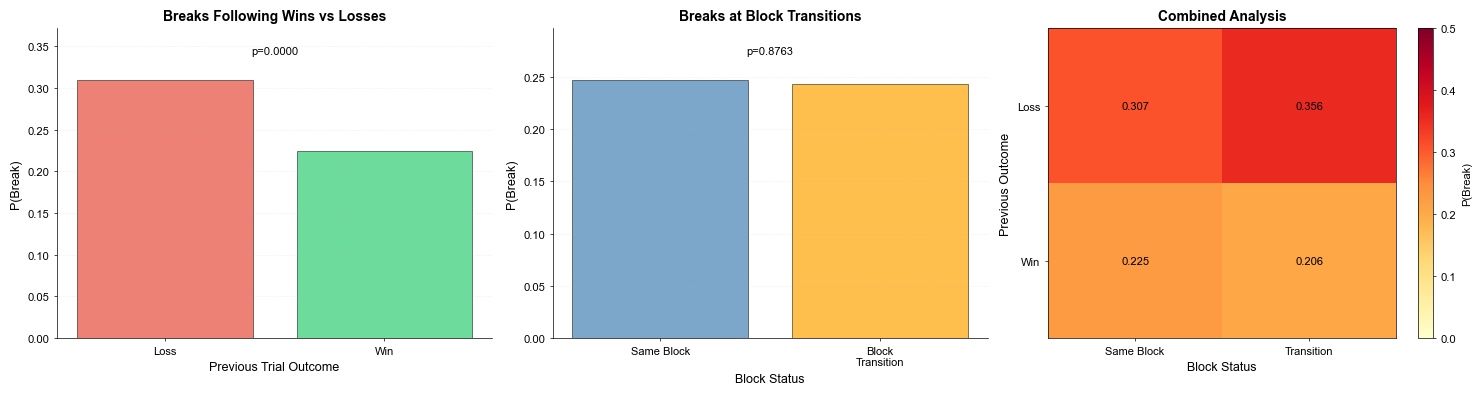


✓ Break analysis figure saved!


In [130]:
# ============================================================================
# Question 1: What Precedes Breaks (Long ITIs)?
# ============================================================================

print("Analyzing what precedes breaks in behavior...\n")

# Calculate ITI if not already present
if 'ITI_calc' not in df.columns:
    df = df.sort_values(['Session_ID', 'Trial']).copy()
    df['Prev_StartTime'] = df.groupby('Session_ID')['AbsoluteTrialStartTime'].shift(1)
    df['ITI_calc'] = (df['AbsoluteTrialStartTime'] - df['Prev_StartTime']) / 1000  # Convert to seconds

# Remove outliers and first trial of each session
df_iti = df[df['ITI_calc'].notna()].copy()

# Define "break" as ITI > threshold (e.g., 75th percentile or > 10 seconds)
iti_threshold = df_iti['ITI_calc'].quantile(0.75)
print(f"ITI threshold (75th percentile): {iti_threshold:.1f} seconds")

df_iti['is_break'] = df_iti['ITI_calc'] > iti_threshold

# Get previous trial info
df_iti['prev_outcome'] = df_iti.groupby('Session_ID')['Outcome'].shift(1)
df_iti['prev_block'] = df_iti.groupby('Session_ID')['Block'].shift(1)
df_iti['block_transition'] = (df_iti['Block'] != df_iti['prev_block']).astype(int)

# Filter out first trial of each session
df_iti = df_iti[df_iti['prev_outcome'].notna()].copy()

print(f"\nTotal trials analyzed: {len(df_iti):,}")
print(f"Trials with breaks (ITI > {iti_threshold:.1f}s): {df_iti['is_break'].sum():,} ({df_iti['is_break'].sum()/len(df_iti)*100:.1f}%)")

# ============================================================================
# Analysis 1: Breaks following wins vs losses
# ============================================================================

print("\n" + "="*70)
print("BREAKS FOLLOWING WINS vs LOSSES")
print("="*70)

# Calculate P(break | outcome)
break_by_outcome = df_iti.groupby('prev_outcome')['is_break'].agg(['mean', 'sum', 'count'])
break_by_outcome.columns = ['p_break', 'n_breaks', 'n_trials']

print("\nP(break | previous outcome):")
print(break_by_outcome)

# Statistical test
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df_iti['prev_outcome'], df_iti['is_break'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square test: χ²={chi2:.2f}, p={p:.4e}")

# ============================================================================
# Analysis 2: Breaks following block transitions
# ============================================================================

print("\n" + "="*70)
print("BREAKS FOLLOWING BLOCK TRANSITIONS")
print("="*70)

break_by_transition = df_iti.groupby('block_transition')['is_break'].agg(['mean', 'sum', 'count'])
break_by_transition.columns = ['p_break', 'n_breaks', 'n_trials']
break_by_transition.index = ['Same Block', 'Block Transition']

print("\nP(break | block transition):")
print(break_by_transition)

contingency2 = pd.crosstab(df_iti['block_transition'], df_iti['is_break'])
chi2_2, p_2, dof_2, expected_2 = chi2_contingency(contingency2)
print(f"\nChi-square test: χ²={chi2_2:.2f}, p={p_2:.4e}")

# ============================================================================
# Analysis 3: Combined - Outcome x Block Transition
# ============================================================================

print("\n" + "="*70)
print("BREAKS BY OUTCOME × BLOCK TRANSITION")
print("="*70)

break_combined = df_iti.groupby(['prev_outcome', 'block_transition'])['is_break'].agg(['mean', 'count'])
break_combined.columns = ['p_break', 'n_trials']

print("\nP(break | outcome, transition):")
print(break_combined.unstack())

# ============================================================================
# Visualization
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel A: Breaks by previous outcome
ax1 = axes[0]

outcomes = ['Loss', 'Win']
p_breaks = [break_by_outcome.loc[0, 'p_break'], break_by_outcome.loc[1, 'p_break']]
colors = ['#e74c3c', '#2ecc71']

bars = ax1.bar(range(2), p_breaks, color=colors, alpha=0.7, 
              edgecolor='black', linewidth=LINE_WIDTH)

ax1.set_xticks(range(2))
ax1.set_xticklabels(outcomes, fontsize=FONTSIZE)
ax1.set_ylabel('P(Break)', fontsize=FONTSIZE+1)
ax1.set_xlabel('Previous Trial Outcome', fontsize=FONTSIZE+1)
ax1.set_title('Breaks Following Wins vs Losses', fontsize=FONTSIZE+2, fontweight='bold')
ax1.set_ylim(0, max(p_breaks) * 1.2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

# Add significance
ax1.text(0.5, max(p_breaks) * 1.1, f'p={p:.4f}', ha='center', fontsize=FONTSIZE)

# Panel B: Breaks by block transition
ax2 = axes[1]

transitions = ['Same Block', 'Block\nTransition']
p_breaks_trans = break_by_transition['p_break'].values
colors_trans = ['steelblue', 'orange']

bars = ax2.bar(range(2), p_breaks_trans, color=colors_trans, alpha=0.7,
              edgecolor='black', linewidth=LINE_WIDTH)

ax2.set_xticks(range(2))
ax2.set_xticklabels(transitions, fontsize=FONTSIZE)
ax2.set_ylabel('P(Break)', fontsize=FONTSIZE+1)
ax2.set_xlabel('Block Status', fontsize=FONTSIZE+1)
ax2.set_title('Breaks at Block Transitions', fontsize=FONTSIZE+2, fontweight='bold')
ax2.set_ylim(0, max(p_breaks_trans) * 1.2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

ax2.text(0.5, max(p_breaks_trans) * 1.1, f'p={p_2:.4f}', ha='center', fontsize=FONTSIZE)

# Panel C: Combined (2x2 heatmap)
ax3 = axes[2]

# Reshape for heatmap
heatmap_data = break_combined['p_break'].unstack().values

im = ax3.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.5)

ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Same Block', 'Transition'], fontsize=FONTSIZE)
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Loss', 'Win'], fontsize=FONTSIZE)
ax3.set_xlabel('Block Status', fontsize=FONTSIZE+1)
ax3.set_ylabel('Previous Outcome', fontsize=FONTSIZE+1)
ax3.set_title('Combined Analysis', fontsize=FONTSIZE+2, fontweight='bold')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax3.text(j, i, f'{heatmap_data[i, j]:.3f}',
                       ha='center', va='center', color='black', fontsize=FONTSIZE)

plt.colorbar(im, ax=ax3, label='P(Break)')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Break_Analysis_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Break analysis figure saved!")
print("="*70)

Analyzing breaks per animal...



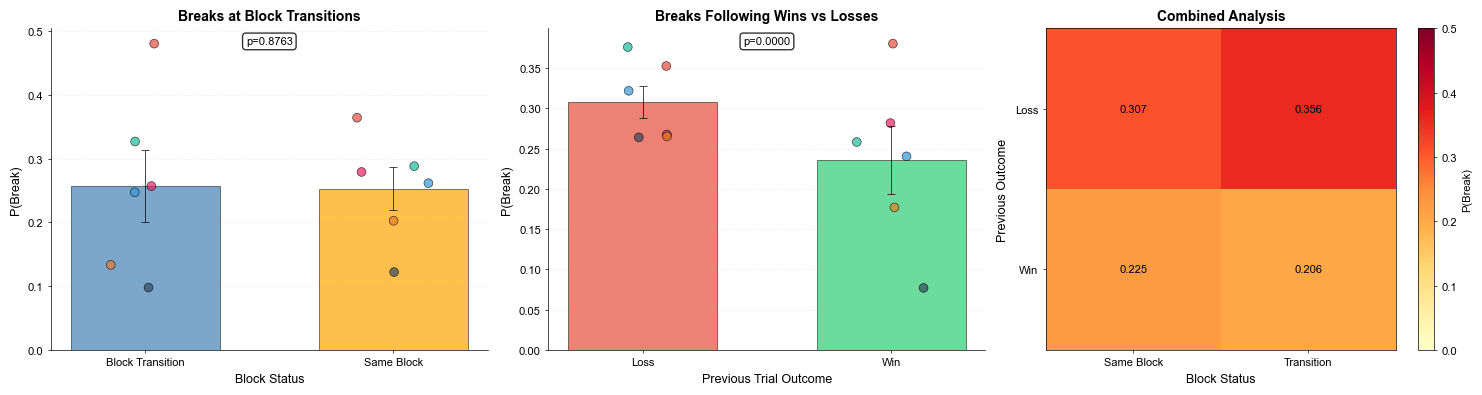


✓ Break analysis (per animal) figure saved!


In [131]:
# ============================================================================
# Break Analysis - Per Animal with Error Bars
# ============================================================================

print("Analyzing breaks per animal...\n")

# Calculate per animal
animal_break_data = []

for animal in sort_animals(df_iti['Animal_Name'].unique()):
    animal_df = df_iti[df_iti['Animal_Name'] == animal]
    
    # By outcome
    for outcome in [0, 1]:
        outcome_trials = animal_df[animal_df['prev_outcome'] == outcome]
        if len(outcome_trials) > 0:
            p_break = outcome_trials['is_break'].mean()
            animal_break_data.append({
                'animal': animal,
                'condition': 'outcome',
                'category': 'Win' if outcome == 1 else 'Loss',
                'p_break': p_break,
                'n': len(outcome_trials)
            })
    
    # By block transition
    for trans in [0, 1]:
        trans_trials = animal_df[animal_df['block_transition'] == trans]
        if len(trans_trials) > 0:
            p_break = trans_trials['is_break'].mean()
            animal_break_data.append({
                'animal': animal,
                'condition': 'transition',
                'category': 'Block Transition' if trans == 1 else 'Same Block',
                'p_break': p_break,
                'n': len(trans_trials)
            })

animal_break_df = pd.DataFrame(animal_break_data)

# ============================================================================
# Visualization - SWAPPED PANELS A and B
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel A: Breaks by block transition (WAS Panel B)
ax1 = axes[0]

transition_summary = animal_break_df[animal_break_df['condition'] == 'transition'].groupby('category').agg({
    'p_break': ['mean', 'sem']
}).reset_index()
transition_summary.columns = ['category', 'mean', 'sem']

x_pos = np.arange(len(transition_summary))
width = 0.6

bars = ax1.bar(x_pos, transition_summary['mean'], width,
              color=['steelblue', 'orange'], alpha=0.7,
              edgecolor='black', linewidth=LINE_WIDTH)

ax1.errorbar(x_pos, transition_summary['mean'], yerr=transition_summary['sem'],
            fmt='none', color='black', linewidth=LINE_WIDTH,
            capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual animal points
for idx, category in enumerate(transition_summary['category']):
    animal_data = animal_break_df[(animal_break_df['condition'] == 'transition') & 
                                   (animal_break_df['category'] == category)]
    
    x_jitter = idx + np.random.uniform(-0.15, 0.15, size=len(animal_data))
    ax1.scatter(x_jitter, animal_data['p_break'], s=40,
               color=[ANIMAL_COLORS[a] for a in animal_data['animal']],
               alpha=0.7, edgecolor='black', linewidth=0.5, zorder=5)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(transition_summary['category'], fontsize=FONTSIZE)
ax1.set_ylabel('P(Break)', fontsize=FONTSIZE+1)
ax1.set_xlabel('Block Status', fontsize=FONTSIZE+1)
ax1.set_title('Breaks at Block Transitions', fontsize=FONTSIZE+2, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax1.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

ax1.text(0.5, ax1.get_ylim()[1] * 0.95, f'p={p_2:.4f}', ha='center', fontsize=FONTSIZE,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel B: Breaks by previous outcome (WAS Panel A)
ax2 = axes[1]

outcome_summary = animal_break_df[animal_break_df['condition'] == 'outcome'].groupby('category').agg({
    'p_break': ['mean', 'sem']
}).reset_index()
outcome_summary.columns = ['category', 'mean', 'sem']
outcome_summary = outcome_summary.sort_values('category')  # Loss, Win

x_pos = np.arange(len(outcome_summary))

bars = ax2.bar(x_pos, outcome_summary['mean'], width,
              color=['#e74c3c', '#2ecc71'], alpha=0.7,
              edgecolor='black', linewidth=LINE_WIDTH)

ax2.errorbar(x_pos, outcome_summary['mean'], yerr=outcome_summary['sem'],
            fmt='none', color='black', linewidth=LINE_WIDTH,
            capsize=3, capthick=LINE_WIDTH, zorder=10)

# Overlay individual animal points
for idx, category in enumerate(outcome_summary['category']):
    animal_data = animal_break_df[(animal_break_df['condition'] == 'outcome') & 
                                   (animal_break_df['category'] == category)]
    
    x_jitter = idx + np.random.uniform(-0.15, 0.15, size=len(animal_data))
    ax2.scatter(x_jitter, animal_data['p_break'], s=40,
               color=[ANIMAL_COLORS[a] for a in animal_data['animal']],
               alpha=0.7, edgecolor='black', linewidth=0.5, zorder=5)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(outcome_summary['category'], fontsize=FONTSIZE)
ax2.set_ylabel('P(Break)', fontsize=FONTSIZE+1)
ax2.set_xlabel('Previous Trial Outcome', fontsize=FONTSIZE+1)
ax2.set_title('Breaks Following Wins vs Losses', fontsize=FONTSIZE+2, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
ax2.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

ax2.text(0.5, ax2.get_ylim()[1] * 0.95, f'p={p:.4f}', ha='center', fontsize=FONTSIZE,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel C: Combined heatmap (same as before)
ax3 = axes[2]

heatmap_data = break_combined['p_break'].unstack().values

im = ax3.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.5)

ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Same Block', 'Transition'], fontsize=FONTSIZE)
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Loss', 'Win'], fontsize=FONTSIZE)
ax3.set_xlabel('Block Status', fontsize=FONTSIZE+1)
ax3.set_ylabel('Previous Outcome', fontsize=FONTSIZE+1)
ax3.set_title('Combined Analysis', fontsize=FONTSIZE+2, fontweight='bold')

for i in range(2):
    for j in range(2):
        text = ax3.text(j, i, f'{heatmap_data[i, j]:.3f}',
                       ha='center', va='center', color='black', fontsize=FONTSIZE)

plt.colorbar(im, ax=ax3, label='P(Break)')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'Break_Analysis_PerAnimal_2ABT.svg'), dpi=300)
plt.show()

print(f"\n✓ Break analysis (per animal) figure saved!")

In [ ]:
# Load all three probability conditions (matched "mixed" sessions)
# ============================================================================

print("Loading matched mixed reversal datasets...\n")

# Load each probability condition
df_100_0 = pd.read_csv(os.path.join(DATAFRAMES_DIR, 'filtered_df_Reversal_100-0_mixed_100.csv'))
df_90_10 = pd.read_csv(os.path.join(DATAFRAMES_DIR, 'filtered_df_Reversal_90-10_mixed_100.csv'))
df_80_20 = pd.read_csv(os.path.join(DATAFRAMES_DIR, 'filtered_df_Reversal_80-20_mixed_100.csv'))

# Add probability condition label to each
df_100_0['prob_condition'] = '100-0'
df_90_10['prob_condition'] = '90-10'
df_80_20['prob_condition'] = '80-20'

# Combine into one dataframe
df_all_mixed = pd.concat([df_100_0, df_90_10, df_80_20], ignore_index=True)

print("="*70)
print("MATCHED MIXED DATASETS LOADED")
print("="*70)

for prob in ['100-0', '90-10', '80-20']:
    prob_data = df_all_mixed[df_all_mixed['prob_condition'] == prob]
    print(f"\n{prob}:")
    print(f"  Sessions: {prob_data['Session_ID'].nunique()}")
    print(f"  Trials: {len(prob_data):,}")
    print(f"  Date range: {prob_data['Date'].min()} to {prob_data['Date'].max()}")
    print(f"  Animals: {sort_animals(prob_data['Animal_Name'].unique())}")

print("\n" + "="*70)
print("COMBINED DATASET")
print("="*70)
print(f"Total sessions: {df_all_mixed['Session_ID'].nunique()}")
print(f"Total trials: {len(df_all_mixed):,}")
print(f"Animals: {sort_animals(df_all_mixed['Animal_Name'].unique())}")

print("\n✓ All mixed datasets loaded and combined")

Loading matched mixed reversal datasets...

MATCHED MIXED DATASETS LOADED

100-0:
  Sessions: 53
  Trials: 11,484
  Date range: 2023-08-11 to 2024-03-25
  Animals: ['Coral', 'Fiona', 'Knuckles', 'Sonic', 'Zazu', 'Sunflower']

90-10:
  Sessions: 55
  Trials: 13,207
  Date range: 2022-05-04 to 2024-03-18
  Animals: ['Fiona', 'Knuckles', 'Sonic', 'Zazu', 'Sunflower']

80-20:
  Sessions: 83
  Trials: 25,906
  Date range: 2022-05-26 to 2024-03-25
  Animals: ['Fiona', 'Knuckles', 'Sonic', 'Zazu', 'Sunflower']

COMBINED DATASET
Total sessions: 191
Total trials: 50,597
Animals: ['Coral', 'Fiona', 'Knuckles', 'Sonic', 'Zazu', 'Sunflower']

✓ All mixed datasets loaded and combined


/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_49974/1381161025.py:10: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  df_80_20 = pd.read_csv(os.path.join(DATAFRAMES_DIR, 'filtered_df_Reversal_80-20_mixed_100.csv'))


In [66]:
# ============================================================================
# Recode Outcome from Reward column
# ============================================================================

print("Recoding Outcome from Reward column...\n")

# Create Outcome column from Reward
df_all_mixed['Outcome'] = df_all_mixed['Reward'].map({
    'Rewarded': 1,
    'Unrewarded': 0
})

print("Outcome recoding:")
print(f"  Total trials: {len(df_all_mixed)}")
print(f"  Rewarded (1): {(df_all_mixed['Outcome'] == 1).sum()}")
print(f"  Unrewarded (0): {(df_all_mixed['Outcome'] == 0).sum()}")
print(f"  Missing: {df_all_mixed['Outcome'].isna().sum()}")

print("\nBy probability condition:")
for prob in ['100-0', '90-10', '80-20']:
    prob_data = df_all_mixed[df_all_mixed['prob_condition'] == prob]
    rewarded = (prob_data['Outcome'] == 1).sum()
    unrewarded = (prob_data['Outcome'] == 0).sum()
    print(f"  {prob}: {rewarded} rewarded, {unrewarded} unrewarded")

print("\n✓ Outcome recoded - now rerun the reversal alignment and plotting code!")

Recoding Outcome from Reward column...

Outcome recoding:
  Total trials: 50597
  Rewarded (1): 32772
  Unrewarded (0): 17730
  Missing: 95

By probability condition:
  100-0: 8394 rewarded, 2995 unrewarded
  90-10: 8782 rewarded, 4425 unrewarded
  80-20: 15596 rewarded, 10310 unrewarded

✓ Outcome recoded - now rerun the reversal alignment and plotting code!


In [67]:
# Classify transitions for all probability conditions
# ============================================================================

print("Classifying transitions across all probability conditions...\n")

# Add absolute trial positions
df_all_mixed = df_all_mixed.sort_values(['Session_ID', 'Block', 'Trial']).reset_index(drop=True)
df_all_mixed['Abs_Trial_Pos'] = df_all_mixed.groupby('Session_ID').cumcount()

# Classify transitions
all_mixed_transitions = []

for session_id in df_all_mixed['Session_ID'].unique():
    session_data = df_all_mixed[df_all_mixed['Session_ID'] == session_id]
    blocks = sorted(session_data['Block'].unique())
    prob_condition = session_data['prob_condition'].iloc[0]
    animal = session_data['Animal_Name'].iloc[0]
    
    for i in range(len(blocks)-1):
        curr_block = blocks[i]
        next_block = blocks[i+1]
        
        curr_trials = session_data[session_data['Block'] == curr_block]
        next_trials = session_data[session_data['Block'] == next_block]
        
        # Get unique locations
        curr_locs = set(curr_trials['PhysicalChoice'].dropna().unique())
        next_locs = set(next_trials['PhysicalChoice'].dropna().unique())
        
        # Classify
        if curr_locs == next_locs:
            trans_type = "UNCUED"
        else:
            trans_type = "CUED"
        
        all_mixed_transitions.append({
            'session_id': session_id,
            'from_block': curr_block,
            'to_block': next_block,
            'transition_type': trans_type,
            'prob_condition': prob_condition,
            'animal': animal
        })

trans_all_mixed_df = pd.DataFrame(all_mixed_transitions)

print("="*70)
print("TRANSITION CLASSIFICATION")
print("="*70)
print(f"\nTotal transitions: {len(trans_all_mixed_df)}")
print(f"\nBy probability and type:")
print(trans_all_mixed_df.groupby(['prob_condition', 'transition_type']).size().unstack(fill_value=0))

# Create reversal-aligned data
reversal_aligned_all_mixed = []

for idx, trans in trans_all_mixed_df.iterrows():
    session_id = trans['session_id']
    to_block = trans['to_block']
    trans_type = trans['transition_type']
    prob_cond = trans['prob_condition']
    animal = trans['animal']
    
    session_data = df_all_mixed[df_all_mixed['Session_ID'] == session_id]
    new_block_trials = session_data[session_data['Block'] == to_block].sort_values('Abs_Trial_Pos')
    
    if len(new_block_trials) > 0:
        reversal_abs_pos = new_block_trials['Abs_Trial_Pos'].iloc[0]
        
        for rel_trial in range(-10, 21):
            abs_pos = reversal_abs_pos + rel_trial
            trial_data = session_data[session_data['Abs_Trial_Pos'] == abs_pos]
            
            if len(trial_data) > 0:
                reversal_aligned_all_mixed.append({
                    'session_id': session_id,
                    'animal': animal,
                    'transition_type': trans_type,
                    'prob_condition': prob_cond,
                    'trial_relative': rel_trial,
                    'outcome': trial_data['Outcome'].iloc[0]
                })

rev_all_mixed_df = pd.DataFrame(reversal_aligned_all_mixed)

print(f"\nReversal-aligned trials: {len(rev_all_mixed_df)}")
print("="*70)

print("\n✓ All probability conditions classified and aligned")

Classifying transitions across all probability conditions...

TRANSITION CLASSIFICATION

Total transitions: 610

By probability and type:
transition_type  CUED  UNCUED
prob_condition               
100-0              62     103
80-20               7     241
90-10              13     184

Reversal-aligned trials: 18654

✓ All probability conditions classified and aligned


In [68]:
# Update figure path for all probabilities
FIGURE_PATH_ALL_PROBS = os.path.join(BASE_PATH, '2-graphs', 'Reversal_All_Probs')
os.makedirs(FIGURE_PATH_ALL_PROBS, exist_ok=True)

print(f"Figure path updated to: {FIGURE_PATH_ALL_PROBS}")


Figure path updated to: /Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs/Reversal_All_Probs


In [69]:
trial_data

,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,Day,Hour,Minute,Second,BehavioralCodes,ObjectStatusRecord,RewardRecord,VariableChanges,CycleRate_1,CycleRate_2,Ver,Target1_name,Target1_x,Target1_y,Target1_xsize,Target1_ysize,Target1_path,Target2_name,Target2_x,Target2_y,Target2_xsize,Target2_ysize,Target2_path,RewardVolume,RewardType,BlockLength,RandomValue,Block_Prob,StimuliChosen,ProbReward,Reward,Animal_Name,Session_Filename,CodeTimes_1,CodeTimes_2,CodeTimes_3,CodeTimes_4,CodeNumbers_1,CodeNumbers_2,CodeNumbers_3,CodeNumbers_4,StartTimes,EndTimes,reward_dur,EyeOffset_1,EyeOffset_2,Eye2Offset_1,Eye2Offset_2,CodeTimes_5,CodeTimes_6,CodeTimes_7,CodeNumbers_5,CodeNumbers_6,CodeNumbers_7,Date,Outcome,Target1_location,Target2_location,Session_ID,PhysicalChoice,PrevPhysicalChoice,PhysicalSwitch,prob_Condition,Task_Type,TaskObject1_Type,TaskObject1_Size_1,TaskObject1_Size_2,TaskObject1_Color_1,TaskObject1_Color_2,TaskObject1_Color_3,TaskObject1_Fill,TaskObject1_LocX,TaskObject1_LocY,TaskObject2_Type,TaskObject2_Source,TaskObject2_LocX,TaskObject2_LocY,TaskObject2_Size1,TaskObject2_Size2,TaskObject3_Type,TaskObject3_Source,TaskObject3_LocX,TaskObject3_LocY,TaskObject3_Size1,TaskObject3_Size2,Session_Type,Num_Reversals,Num_Cued_Transitions,Has_Cued_Transitions,prob_condition,filename_part_0,filename_part_1,filename_part_2,filename_part_3,filename_part_4,filename_part_5,filename_part_6,filename_part_7,Session_ID_Trial,Switch,Decision,Target,TrialStartTime_seconds,TrialStartTime_mins,ITI,filename,Abs_Trial_Pos
50537,141,8,1,4,4,0,NaN,908425.0325,2024,3,25,12,0,27.881,NaN,NaN,NaN,NaN,16.669,3.3774,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,90:10 AppleJuice:Water,20.0,13.0,3.0,TargetA,0.8,Rewarded,Fiona,NaN,0.2968,48.4347,54.8165,55.7415,9.0,40.0,80.0,50.0,55.7415,156.4216,100.0,0.0,0.0,0.0,0.0,181.7496,201.9453,248.4564,70.0,90.0,18.0,2024-03-25,1.0,NaN,NaN,2024-03-25_Fiona,0.0,NaN,0.0,80-20,Reversal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mixed,2.0,1.0,True,80-20,240325.0,Fiona,VDT,NoInitiation,100.0,Conflict,Reversal3.1.csv,NaN,2024-03-25_Fiona_141,1.0,1.0,1.0,908.425033,15.140417,4.53284,240325 Fiona VDT NoInitiation 100.0 Conflict R...,282


In [70]:
rev_all_mixed_df

,session_id,animal,transition_type,prob_condition,trial_relative,outcome
0,2022-05-04_Zazu,Zazu,UNCUED,90-10,-10,0.0
1,2022-05-04_Zazu,Zazu,UNCUED,90-10,-9,0.0
2,2022-05-04_Zazu,Zazu,UNCUED,90-10,-8,0.0
3,2022-05-04_Zazu,Zazu,UNCUED,90-10,-7,0.0
4,2022-05-04_Zazu,Zazu,UNCUED,90-10,-6,0.0
...,...,...,...,...,...,...
18649,2024-03-25_Fiona,Fiona,UNCUED,80-20,16,1.0
18650,2024-03-25_Fiona,Fiona,UNCUED,80-20,17,1.0
18651,2024-03-25_Fiona,Fiona,UNCUED,80-20,18,1.0
18652,2024-03-25_Fiona,Fiona,UNCUED,80-20,19,1.0


In [72]:
trans_all_mixed_df

,session_id,from_block,to_block,transition_type,prob_condition,animal
0,2022-05-04_Zazu,1,2,UNCUED,90-10,Zazu
1,2022-05-04_Zazu,2,3,UNCUED,90-10,Zazu
2,2022-05-04_Zazu,3,4,UNCUED,90-10,Zazu
3,2022-05-05_Zazu,5,6,UNCUED,90-10,Zazu
4,2022-05-05_Zazu,6,7,UNCUED,90-10,Zazu
...,...,...,...,...,...,...
605,2024-03-25_240325_Coral_VDT_NoInitiation_100%C...,3,4,UNCUED,100-0,Coral
606,2024-03-25_240325_Coral_VDT_NoInitiation_100%C...,4,9,CUED,100-0,Coral
607,2024-03-25_Fiona,1,2,UNCUED,80-20,Fiona
608,2024-03-25_Fiona,2,3,UNCUED,80-20,Fiona


Creating probability comparison figure...



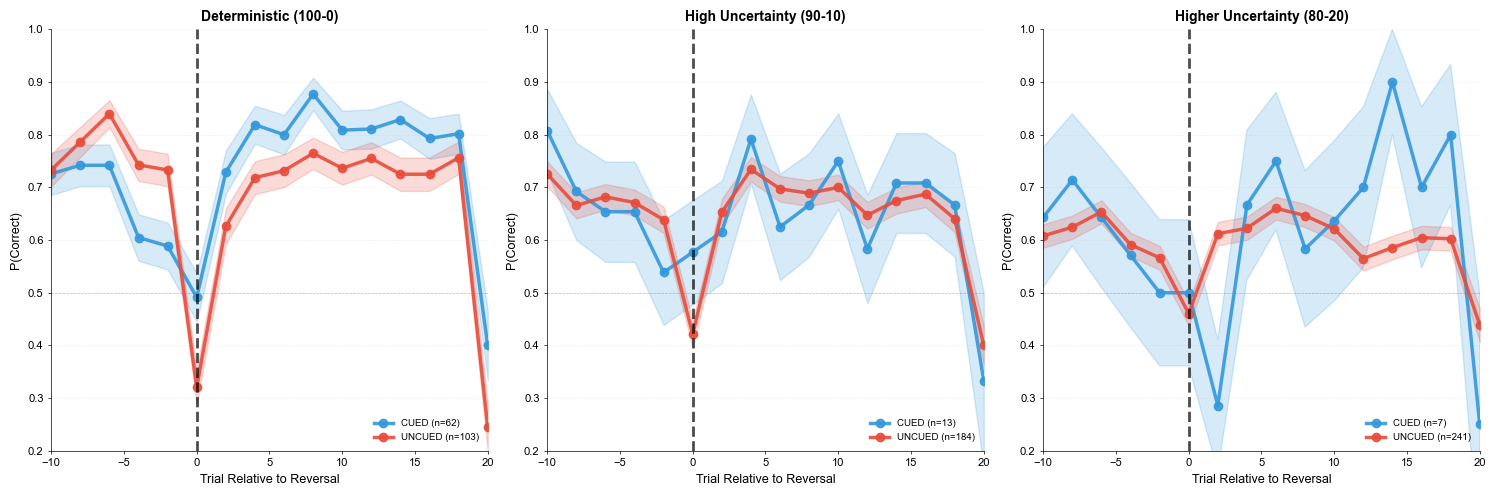


✓ Probability comparison figure created!


In [71]:
# ============================================================================
# Figure: Reversal Learning Across Probability Conditions
# ============================================================================

print("Creating probability comparison figure...\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

BIN_SIZE = 2
prob_conditions = ['100-0', '90-10', '80-20']
titles = ['Deterministic (100-0)', 'High Uncertainty (90-10)', 'Higher Uncertainty (80-20)']

for ax, prob_cond, title in zip(axes, prob_conditions, titles):
    prob_data = rev_all_mixed_df[rev_all_mixed_df['prob_condition'] == prob_cond]
    
    for trans_type, color in [('CUED', '#3498db'), ('UNCUED', '#e74c3c')]:
        type_data = prob_data[prob_data['transition_type'] == trans_type].copy()
        
        if len(type_data) > 0:
            # Count unique reversals
            n_reversals = len(trans_all_mixed_df[
                (trans_all_mixed_df['prob_condition'] == prob_cond) & 
                (trans_all_mixed_df['transition_type'] == trans_type)
            ])
            
            type_data['trial_bin'] = (type_data['trial_relative'] // BIN_SIZE) * BIN_SIZE
            
            binned = type_data.groupby('trial_bin').agg({
                'outcome': ['mean', 'sem']
            }).reset_index()
            binned.columns = ['trial_bin', 'accuracy', 'sem']
            
            ax.plot(binned['trial_bin'], binned['accuracy'],
                   'o-', color=color, linewidth=2.5, markersize=6,
                   label=f'{trans_type} (n={n_reversals})', alpha=0.9)
            ax.fill_between(binned['trial_bin'],
                            binned['accuracy'] - binned['sem'],
                            binned['accuracy'] + binned['sem'],
                            color=color, alpha=0.2)
    
    ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=LINE_WIDTH, alpha=0.5)
    ax.set_xlabel('Trial Relative to Reversal', fontsize=FONTSIZE+1)
    ax.set_ylabel('P(Correct)', fontsize=FONTSIZE+1)
    ax.set_title(title, fontsize=FONTSIZE+2, fontweight='bold')
    ax.set_xlim(-10, 20)
    ax.set_ylim(0.2, 1.0)
    ax.legend(fontsize=FONTSIZE-1, frameon=False, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle=':', linewidth=LINE_WIDTH)
    ax.tick_params(axis='both', labelsize=FONTSIZE, length=TICK_LENGTH)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH_ALL_PROBS, 'Reversal_Learning_by_Probability.svg'), dpi=300)
plt.show()

print("\n✓ Probability comparison figure created!")

In [73]:
df_all_mixed

,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,Day,Hour,Minute,Second,BehavioralCodes,ObjectStatusRecord,RewardRecord,VariableChanges,CycleRate_1,CycleRate_2,Ver,Target1_name,Target1_x,Target1_y,Target1_xsize,Target1_ysize,Target1_path,Target2_name,Target2_x,Target2_y,Target2_xsize,Target2_ysize,Target2_path,RewardVolume,RewardType,BlockLength,RandomValue,Block_Prob,StimuliChosen,ProbReward,Reward,Animal_Name,Session_Filename,CodeTimes_1,CodeTimes_2,CodeTimes_3,CodeTimes_4,CodeNumbers_1,CodeNumbers_2,CodeNumbers_3,CodeNumbers_4,StartTimes,EndTimes,reward_dur,EyeOffset_1,EyeOffset_2,Eye2Offset_1,Eye2Offset_2,CodeTimes_5,CodeTimes_6,CodeTimes_7,CodeNumbers_5,CodeNumbers_6,CodeNumbers_7,Date,Outcome,Target1_location,Target2_location,Session_ID,PhysicalChoice,PrevPhysicalChoice,PhysicalSwitch,prob_Condition,Task_Type,TaskObject1_Type,TaskObject1_Size_1,TaskObject1_Size_2,TaskObject1_Color_1,TaskObject1_Color_2,TaskObject1_Color_3,TaskObject1_Fill,TaskObject1_LocX,TaskObject1_LocY,TaskObject2_Type,TaskObject2_Source,TaskObject2_LocX,TaskObject2_LocY,TaskObject2_Size1,TaskObject2_Size2,TaskObject3_Type,TaskObject3_Source,TaskObject3_LocX,TaskObject3_LocY,TaskObject3_Size1,TaskObject3_Size2,Session_Type,Num_Reversals,Num_Cued_Transitions,Has_Cued_Transitions,prob_condition,filename_part_0,filename_part_1,filename_part_2,filename_part_3,filename_part_4,filename_part_5,filename_part_6,filename_part_7,Session_ID_Trial,Switch,Decision,Target,TrialStartTime_seconds,TrialStartTime_mins,ITI,filename,Abs_Trial_Pos
0,1,1,1,1,1,6,NaN,0.000000e+00,2022,5,4,11,35,27.416,NaN,NaN,NaN,NaN,33.3331,22.8703,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,80:20 Sweetened:Unsweetened Vanilla Almond Milk,20.0,11.0,2.0,TargetB,0.1,Unrewarded,Zazu,NaN,2.2768,299.4009,1160.4417,1249.2975,9.0,40.0,80.0,70.0,NaN,NaN,100.0,0.0,0.0,0.0,0.0,1288.7899,1333.4887,NaN,90.0,18.0,NaN,2022-05-04,0.0,NaN,NaN,2022-05-04_Zazu,0.0,NaN,0.0,90-10,Reversal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mixed,2.0,1.0,True,90-10,20220504.0,Zazu,Reversal2.1.csv,NaN,NaN,NaN,NaN,NaN,2022-05-04_Zazu_1,NaN,0.0,1.0,0.000000,0.000000,NaN,20220504 Zazu Reversal2.1.csv nan nan nan nan,0
1,2,1,2,1,1,0,NaN,3.335660e+03,2022,5,4,11,35,30.751,NaN,NaN,NaN,NaN,33.3298,7.6220,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,80:20 Sweetened:Unsweetened Vanilla Almond Milk,20.0,15.0,2.0,TargetA,0.9,Rewarded,Zazu,NaN,1.5217,80.0533,557.0216,948.7359,9.0,40.0,80.0,50.0,948.7359,1051.0179,100.0,0.0,0.0,0.0,0.0,1079.9446,1120.8469,1180.2943,70.0,90.0,18.0,2022-05-04,1.0,NaN,NaN,2022-05-04_Zazu,1.0,NaN,1.0,90-10,Reversal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mixed,2.0,1.0,True,90-10,20220504.0,Zazu,Reversal2.1.csv,NaN,NaN,NaN,NaN,NaN,2022-05-04_Zazu_2,1.0,1.0,1.0,3.335660,0.055594,3.335660,20220504 Zazu Reversal2.1.csv nan nan nan nan,1
2,3,1,3,1,1,6,NaN,6.518006e+03,2022,5,4,11,35,33.934,NaN,NaN,NaN,NaN,66.6587,9.1621,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,80:20 Sweetened:Unsweetened Vanilla Almond Milk,20.0,18.0,2.0,TargetB,0.1,Unrewarded,Zazu,NaN,1.1859,80.6859,245310.8287,245336.4186,9.0,40.0,80.0,70.0,NaN,NaN,100.0,0.0,0.0,0.0,0.0,245441.5283,245486.7414,NaN,90.0,18.0,NaN,2022-05-04,0.0,NaN,NaN,2022-05-04_Zazu,0.0,NaN,1.0,90-10,Reversal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mixed,2.0,1.0,True,90-10,20220504.0,Zazu,Reversal2.1.csv,NaN,NaN,NaN,NaN,NaN,2022-05-04_Zazu_3,1.0,0.0,1.0,6.518006,0.108633,3.182346,20220504 Zazu Reversal2.1.csv nan nan nan nan,2
3,4,1,4,1,1,6,NaN,2.540068e+05,2022,5,4,11,39,41.415,NaN,NaN,NaN,NaN,33.3006,4.9350,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07,80:20 Sweetened:Unsweetened Vanilla Almond Milk,20.0,20.0,2.0,TargetB,0.1,Unrewarded,Zazu,NaN,2.1327,64.0801,44198.3835,44209.0630,9.0,40.0,80.0,70.0,NaN,NaN,100.0,0.0,0.0,0.0,0.0,44296.6337,443

In [ ]:
# ============================================================================
# FIXED: Classify transitions using actual spatial locations
# ============================================================================

print("Re-classifying transitions using actual spatial locations...\n")

# First, fill in missing Target locations from TaskObject coordinates
def get_location_from_coords(x, y):
    """Convert TaskObject X,Y coordinates to location name"""
    if pd.isna(x) or pd.isna(y):
        return None
    
    # Define location mappings (approximate)
    if x < -5 and y > 5:
        return "TopLeft"
    elif x > 5 and y > 5:
        return "TopRight"
    elif x < -5 and y < -5:
        return "BottomLeft"
    elif x > 5 and y < -5:
        return "BottomRight"
    elif x < -2:
        return "LeftCenter"
    elif x > 2:
        return "RightCenter"
    else:
        return None

# Fill in Target locations where they're missing
for idx, row in df_all_mixed.iterrows():
    if pd.isna(row['Target1_location']) or row['Target1_location'] == 'LOCATION_NEEDED':
        loc1 = get_location_from_coords(row['TaskObject2_LocX'], row['TaskObject2_LocY'])
        loc2 = get_location_from_coords(row['TaskObject3_LocX'], row['TaskObject3_LocY'])
        
        if loc1:
            df_all_mixed.at[idx, 'Target1_location'] = loc1
        if loc2:
            df_all_mixed.at[idx, 'Target2_location'] = loc2

print("Filled missing locations from TaskObject coordinates")

# Now reclassify transitions using actual locations
all_mixed_transitions_fixed = []

for session_id in df_all_mixed['Session_ID'].unique():
    session_data = df_all_mixed[df_all_mixed['Session_ID'] == session_id]
    blocks = sorted(session_data['Block'].unique())
    prob_condition = session_data['prob_condition'].iloc[0]
    animal = session_data['Animal_Name'].iloc[0]
    
    for i in range(len(blocks)-1):
        curr_block = blocks[i]
        next_block = blocks[i+1]
        
        curr_trials = session_data[session_data['Block'] == curr_block]
        next_trials = session_data[session_data['Block'] == next_block]
        
        # Get unique ACTUAL locations from each block
        curr_locs = set()
        curr_locs.update(curr_trials['Target1_location'].dropna().unique())
        curr_locs.update(curr_trials['Target2_location'].dropna().unique())
        curr_locs.discard('LOCATION_NEEDED')
        
        next_locs = set()
        next_locs.update(next_trials['Target1_location'].dropna().unique())
        next_locs.update(next_trials['Target2_location'].dropna().unique())
        next_locs.discard('LOCATION_NEEDED')
        
        # Only classify if we have locations for both blocks
        if len(curr_locs) > 0 and len(next_locs) > 0:
            if curr_locs == next_locs:
                trans_type = "UNCUED"
            else:
                trans_type = "CUED"
            
            all_mixed_transitions_fixed.append({
                'session_id': session_id,
                'from_block': curr_block,
                'to_block': next_block,
                'transition_type': trans_type,
                'prob_condition': prob_condition,
                'animal': animal,
                'curr_locs': curr_locs,
                'next_locs': next_locs
            })

trans_all_mixed_df = pd.DataFrame(all_mixed_transitions_fixed)

print("\n" + "="*70)
print("FIXED TRANSITION CLASSIFICATION (Using Actual Locations)")
print("="*70)
print(f"\nTotal transitions: {len(trans_all_mixed_df)}")
print(f"\nBy probability and type:")
print(trans_all_mixed_df.groupby(['prob_condition', 'transition_type']).size().unstack(fill_value=0))
print("="*70)

# Show some examples
print("\nExample transitions:")
for prob in ['100-0', '90-10', '80-20']:
    prob_trans = trans_all_mixed_df[trans_all_mixed_df['prob_condition'] == prob].head(2)
    if len(prob_trans) > 0:
        print(f"\n{prob}:")
        for _, trans in prob_trans.iterrows():
            print(f"  {trans['transition_type']}: {trans['curr_locs']} → {trans['next_locs']}")

print("\n✓ Now rerun reversal alignment and plotting!")